# Graph Neural Networks for Drug Discovery
### A Foundational Learning Project

---

## Full Notebook Outline

| Section | Title | Status |
|---------|-------|--------|
| 0 | Project Framing | ✅ Implemented |
| 1 | Dataset Loading | ✅ Implemented |
| 2 | Molecular Representation | ✅ Implemented |
| 3 | Feature Engineering | ✅ Implemented |
| 4 | Train/Test Split | ✅ Implemented |
| 5 | Baseline Model (Morgan Fingerprints + RF) | ✅ Implemented |
| 6 | Simple GCN Model | ✅ Implemented |
| 7 | Training Loop | ✅ Implemented |
| 8 | Evaluation | ✅ Implemented |
| 9 | GIN Model + Comparison | ✅ Implemented |
| 10 | Drug Development Interpretation | ✅ Implemented |
| 11 | Optional Extensions | ✅ Implemented |
| 12 | What's Next — The Full Learning Roadmap | ✅ Implemented |
| 13 | Key Papers Reading List | ✅ Implemented |

---

**How to use this notebook:**
Run one section at a time. Read the explanation before each code cell. After running, check your output against the expected output described below each cell.

---
# Section 0: Project Framing

Before writing any code, let's make sure we understand what we're actually doing and why.

## What is drug discovery, in plain English?

Developing a new drug takes roughly 10–15 years and over a billion dollars. Most of that time and money is spent on **failure** — testing molecules that turn out to be toxic, don't work, or can't even reach the target organ.

The early stage of drug discovery looks like this:

```
You have a disease target (e.g. a protein that causes cancer)
    ↓
You need a molecule that binds to it and changes its behavior
    ↓
There are billions of possible drug-like molecules
    ↓
You cannot test all of them in the lab — that would take centuries
    ↓
So you use computation to PRIORITIZE which molecules to actually test
```

This prioritization step is called **virtual screening** or **computational screening**.

One huge part of it is **molecular property prediction**: given a molecule's structure, can we predict properties that matter for a drug?

Properties that matter include:
- **Solubility** — can the molecule dissolve in water? (If not, it can't travel through the bloodstream)
- **Blood-brain barrier penetration** — can it reach the brain? (Matters for neurological drugs)
- **Toxicity** — will it kill cells it shouldn't kill?
- **Binding affinity** — does it actually bind to the disease target?
- **Bioavailability** — can the body absorb and use it?

These properties are collectively called **ADMET** properties:
- **A**bsorption
- **D**istribution
- **M**etabolism
- **E**xcretion
- **T**oxicity

In this project, we will build a machine learning model that predicts **aqueous solubility** — one of the most fundamental and commonly predicted ADMET properties.

---

## Why GNNs? What's wrong with regular machine learning?

A molecule is not a list of numbers. It's a **graph**.

- Atoms are **nodes**
- Bonds between atoms are **edges**

Traditional machine learning needs a fixed-size vector as input. So the traditional approach was to convert molecules into fixed-length "fingerprints" — essentially a bag-of-features that ignores the graph structure.

**Graph Neural Networks (GNNs)** can operate directly on the graph structure. Instead of flattening the molecule into a fixed vector, the GNN lets each atom communicate with its bonded neighbors and build up a rich, learned representation of the molecule.

This is closer to how chemists actually think about molecules — as structured, connected objects where local chemical environment matters.

---

## What we ARE and are NOT claiming

| We ARE doing | We are NOT doing |
|---|---|
| Learning how to represent molecules as graphs | Discovering a real drug |
| Training a GNN to predict a molecular property from structure | Proving biological activity in a lab |
| Learning the core ML pipeline used in computational chemistry | Running wet-lab experiments |
| Building intuition for how GNNs capture chemical structure | Guaranteeing any prediction is accurate enough for real use |
| Understanding one piece of a larger drug discovery workflow | Replacing any part of clinical trials |

This project is a **pedagogical implementation** of a real and important technique. The same core ideas are used by pharmaceutical companies and research labs today — but the real versions use larger datasets, more features, more careful validation, and much more domain expertise.

---

## The pipeline we will build

```
SMILES string (text representation of a molecule)
    ↓
RDKit molecule object (parsed chemical structure)
    ↓
Molecular graph (atoms as nodes, bonds as edges)
    ↓
Atom features as node feature matrix  (shape: [num_atoms, num_features])
    ↓
Bond connections as edge index         (shape: [2, num_bonds*2])
    ↓
Graph Neural Network — message passing
    ↓
Graph-level molecular embedding        (shape: [1, hidden_dim])
    ↓
Linear layer — property prediction
    ↓
Predicted solubility value
    ↓
Comparison to actual measured value → RMSE, MAE, R²
```

Let's build it one step at a time.

---
# Section 1: Dataset Loading

**What we're doing:** Loading a real molecular dataset with measured solubility values.

**Why it matters:** We need real experimental data to train and evaluate our model. Without measured ground-truth values, we have nothing to learn from.

**The dataset: ESOL (Estimated SOLubility)**

ESOL is a classic benchmark dataset in computational chemistry, published by John Delaney in 2004. It contains:
- **1,128 organic molecules**
- Each molecule represented as a SMILES string
- Each molecule paired with its measured **aqueous solubility** in log mol/L

**What is SMILES?** SMILES stands for *Simplified Molecular Input Line Entry System*. It's a way to write a molecule's structure as a text string. For example:
- Water: `O`
- Ethanol: `CCO`
- Aspirin: `CC(=O)Oc1ccccc1C(=O)O`

**What is solubility?** Solubility measures how much of a substance dissolves in water. We measure it in log mol/L (the log scale is used because solubility spans many orders of magnitude). Higher values = more soluble.

**Why does solubility matter for drugs?** A drug needs to dissolve in bodily fluids to be absorbed and transported to where it needs to work. Poorly soluble drugs have low bioavailability — the body can't use them efficiently. Roughly 40% of drug candidates fail partly due to poor solubility.

## Step 1.1 — Install dependencies

We need two libraries that aren't pre-installed in Colab:
- **RDKit** — the standard open-source cheminformatics library. We'll use it to parse SMILES strings into molecule objects and extract atom/bond information.

The cell below installs RDKit. In Colab, this uses `pip`.

> **If this install fails:** The most common reason is a network timeout. Just re-run the cell. If it still fails, try restarting the Colab runtime and running again.

In [1]:
# Install RDKit — the chemistry library we'll use throughout this project.
# This may take 30-60 seconds in Colab.
!pip install rdkit --quiet

print("Install complete. If you see no errors above, you're good to go.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 30.0 MB/s eta 0:00:00
Install complete. If you see no errors above, you're good to go.


## Step 1.2 — Import libraries

Let's import everything we need for this section and confirm our environment is working.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# RDKit — for chemistry
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import rdMolDescriptors

# For displaying molecule images inside the notebook
from IPython.display import display, Image
import io

# Suppress RDKit warnings that aren't useful for learning
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("Imports successful.")

# Confirm RDKit version
from rdkit import __version__ as rdkit_version
print(f"RDKit version: {rdkit_version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")

Imports successful.
RDKit version: 2026.03.2
Pandas version: 2.2.2
NumPy version:  2.0.2


## Step 1.3 — Load the ESOL dataset

We'll load the ESOL dataset directly from a publicly hosted CSV. This is the canonical version of the dataset as distributed by MoleculeNet.

The CSV has two columns we care about:
- `smiles` — the SMILES string representing the molecule
- `measured log solubility in mols per litre` — the experimentally measured solubility value

We'll rename that long column to `solubility` for readability.

> **What if the URL fails?** We include a fallback that downloads from an alternative source. If both fail, a manual download link is printed.

In [3]:
# -------------------------------------------------------
# Load the ESOL solubility dataset
# -------------------------------------------------------

# Primary source: MoleculeNet's hosted version of the Delaney ESOL dataset
ESOL_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"

# Fallback source in case the primary is unavailable
ESOL_FALLBACK_URL = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"

try:
    df = pd.read_csv(ESOL_URL)
    print("Loaded from primary source.")
except Exception as e:
    print(f"Primary source failed ({e}). Trying fallback...")
    try:
        df = pd.read_csv(ESOL_FALLBACK_URL)
        print("Loaded from fallback source.")
    except Exception as e2:
        print(f"Both sources failed. Error: {e2}")
        print("Manual download: https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv")
        raise

print(f"\nDataset loaded. Shape: {df.shape}  ({df.shape[0]} molecules, {df.shape[1]} columns)")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  {col}")

Loaded from primary source.

Dataset loaded. Shape: (1128, 10)  (1128 molecules, 10 columns)

Column names:
  Compound ID
  ESOL predicted log solubility in mols per litre
  Minimum Degree
  Molecular Weight
  Number of H-Bond Donors
  Number of Rings
  Number of Rotatable Bonds
  Polar Surface Area
  measured log solubility in mols per litre
  smiles


### Understanding the ESOL Dataset Columns

Here is a breakdown of the features included in this dataset. While our GNN will learn its own features from the raw graph, these columns represent traditional chemical 'descriptors':

| Column Name | Description |
|:---|:---|
| **Compound ID** | The common name or identifier for the molecule (e.g., Aspirin, Benzene). |
| **smiles** | The text-based 'DNA' of the molecule. This is our primary input for the GNN. |
| **measured log solubility...** | **Our Target.** The actual experimental value we want our model to predict. |
| **ESOL predicted...** | This is the prediction made by the original 2004 'ESOL' linear model. We can use this as a benchmark. |
| **Molecular Weight** | The 'size' of the molecule. Heavier molecules often (but not always) dissolve more slowly. |
| **Number of Rings** | How many closed loops (like Benzene rings) are in the structure. More rings often mean lower solubility. |
| **Number of Rotatable Bonds** | A measure of how 'flexible' the molecule is. High flexibility can affect how easily a molecule fits into a crystal lattice. |
| **Polar Surface Area (PSA)** | Measures how much of the molecule's surface is 'polar' (likes water). Higher PSA usually helps solubility. |
| **H-Bond Donors** | Number of atoms (like O-H or N-H) that can form hydrogen bonds with water. More donors usually = better solubility. |
| **Minimum Degree** | A structural graph property representing the minimum number of bonds attached to any single non-hydrogen atom. |


**Notes from Pranav:**
1. More Benzene Rings means less solubility because benzene rings are hydrophobic and non polar
2. More rotatable bonds = more flexiblity = easier to be soluble

## Step 1.4 — Clean up column names

The original column name is very long. Let's rename it to something manageable.

We also keep the compound name if present, just for human readability.

In [4]:
# The target column has a long name — rename it for convenience.
# We look for it by checking which column contains 'solubility' in its name.

solubility_col = [c for c in df.columns if 'solubility' in c.lower()]
print(f"Found solubility column(s): {solubility_col}")

# Rename to 'solubility'
df = df.rename(columns={solubility_col[0]: 'solubility'})

# Look for a compound name column to keep for readability
name_col = [c for c in df.columns if 'compound' in c.lower() or 'name' in c.lower()]
print(f"Found name column(s): {name_col}")

# Keep only the columns we need for this project
keep_cols = ['smiles', 'solubility']
if name_col:
    keep_cols = [name_col[0]] + keep_cols
    df = df.rename(columns={name_col[0]: 'compound_name'})
    keep_cols[0] = 'compound_name'

df = df[keep_cols].copy()

print(f"\nDataset after cleanup:")
print(df.head(5).to_string())

Found solubility column(s): ['ESOL predicted log solubility in mols per litre', 'measured log solubility in mols per litre']
Found name column(s): ['Compound ID']

Dataset after cleanup:
  compound_name                                                  smiles  solubility
0     Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O       -0.974
1      Fenfuram                                  Cc1occc1C(=O)Nc2ccccc2      -2.885
2        citral                                    CC(C)=CCCC(C)=CC(=O)      -2.579
3        Picene                      c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43      -6.618
4     Thiophene                                                 c1ccsc1      -2.232


## Step 1.5 — Basic exploration

Before building any model, always look at your data.

We want to know:
1. How many molecules do we have?
2. Are there missing values?
3. What does the target (solubility) look like?
4. What does a SMILES string actually look like?

This step matters because:
- Missing SMILES strings would crash the molecule parser later
- Understanding the target distribution tells us if this is an easy or hard regression problem
- It builds intuition for what the data represents

In [5]:
# -------------------------------------------------------
# 1. Size and missing values
# -------------------------------------------------------

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total molecules:    {len(df)}")
print(f"Columns:            {list(df.columns)}")

print("\nMissing values per column:")
print(df.isnull().sum())

# -------------------------------------------------------
# 2. Target variable statistics
# -------------------------------------------------------

print("\n" + "=" * 50)
print("TARGET VARIABLE: Solubility (log mol/L)")
print("=" * 50)
stats = df['solubility'].describe()
print(f"  Mean:   {stats['mean']:.3f}")
print(f"  Std:    {stats['std']:.3f}")
print(f"  Min:    {stats['min']:.3f}")
print(f"  Max:    {stats['max']:.3f}")
print(f"  Median: {df['solubility'].median():.3f}")

print("\nInterpretation:")
print("  Values near 0  → moderately soluble (dissolves well)")
print("  Values near -5 → poorly soluble (hard to dissolve)")
print("  Values near +1 → highly soluble")
print("  This is log scale: a difference of 1 = 10x difference in solubility")

DATASET OVERVIEW
Total molecules:    1128
Columns:            ['compound_name', 'smiles', 'solubility']

Missing values per column:
compound_name    0
smiles           0
solubility       0
dtype: int64

TARGET VARIABLE: Solubility (log mol/L)
  Mean:   -2.988
  Std:    1.683
  Min:    -9.702
  Max:    1.091
  Median: -2.870

Interpretation:
  Values near 0  → moderately soluble (dissolves well)
  Values near -5 → poorly soluble (hard to dissolve)
  Values near +1 → highly soluble
  This is log scale: a difference of 1 = 10x difference in solubility


## Step 1.6 — Look at some SMILES examples

Let's print a few SMILES strings so you can see what the raw input looks like. At this stage, you don't need to be able to read SMILES — just notice that it's a text string encoding molecular structure.

In [6]:
# -------------------------------------------------------
# Show some SMILES examples across the solubility range
# -------------------------------------------------------

print("=" * 60)
print("EXAMPLE MOLECULES — sorted by solubility")
print("=" * 60)

# Get examples from different parts of the solubility range
df_sorted = df.sort_values('solubility')

# Take 3 from the least soluble, 2 from the middle, 3 from the most soluble
examples = pd.concat([
    df_sorted.head(3),
    df_sorted.iloc[len(df_sorted)//2 - 1 : len(df_sorted)//2 + 1],
    df_sorted.tail(3)
])

for idx, row in examples.iterrows():
    name = row.get('compound_name', f'Molecule {idx}')
    print(f"\n  Name:        {name}")
    print(f"  SMILES:      {row['smiles']}")
    print(f"  Solubility:  {row['solubility']:.3f} log mol/L")

    # Add a human-readable interpretation
    if row['solubility'] > -1:
        print(f"  Category:    Highly soluble")
    elif row['solubility'] > -3:
        print(f"  Category:    Moderately soluble")
    elif row['solubility'] > -5:
        print(f"  Category:    Slightly soluble")
    else:
        print(f"  Category:    Poorly soluble")

EXAMPLE MOLECULES — sorted by solubility

  Name:        hexacosane
  SMILES:      CCCCCCCCCCCCCCCCCCCCCCCCCC
  Solubility:  -9.702 log mol/L
  Category:    Poorly soluble

  Name:        2,2',3,3',4,4',5,5',6,6'-PCB
  SMILES:      Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl 
  Solubility:  -9.589 log mol/L
  Category:    Poorly soluble

  Name:        2,2',3,3',4,4',5,5'-PCB
  SMILES:      Clc1cc(c(Cl)c(Cl)c1Cl)c2cc(Cl)c(Cl)c(Cl)c2Cl
  Solubility:  -8.468 log mol/L
  Category:    Poorly soluble

  Name:        metalaxyl
  SMILES:      COCC(=O)N(C(C)C(=O)OC)c1c(C)cccc1C 
  Solubility:  -2.870 log mol/L
  Category:    Moderately soluble

  Name:        thioanisole
  SMILES:      c1ccccc1SC
  Solubility:  -2.870 log mol/L
  Category:    Moderately soluble

  Name:        alloxantin
  SMILES:      C1(=O)NC(=O)NC(=O)C1(O)C2(O)C(=O)NC(=O)NC2(=O)
  Solubility:  0.919 log mol/L
  Category:    Highly soluble

  Name:        Lactose
  SMILES:      OCC1OC(OC2C(O)C(O)C(O)OC2CO)C(O)C(O)C1

## Step 1.7 — Validate that RDKit can parse all SMILES strings

Before we go further, we need to check that every SMILES string in the dataset can actually be converted into a molecule object by RDKit.

**What is an RDKit molecule object?** It's a Python object representing a parsed, validated molecule. From it, we can extract atoms, bonds, coordinates, and features. If RDKit can't parse a SMILES string, it returns `None`.

**What can go wrong:** Some SMILES strings in datasets have typos, unusual notation, or represent molecules with valence errors. We want to catch these now rather than have them silently fail later.

In [7]:
# -------------------------------------------------------
# Try to parse every SMILES string with RDKit
# -------------------------------------------------------

def try_parse_smiles(smiles):
    """Returns the RDKit mol object, or None if parsing fails."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol  # This is None if RDKit couldn't parse it
    except Exception:
        return None

print("Attempting to parse all SMILES strings...")
df['mol'] = df['smiles'].apply(try_parse_smiles)

# Count successes and failures
n_total = len(df)
n_valid = df['mol'].notna().sum()
n_invalid = df['mol'].isna().sum()

print(f"\nTotal molecules:      {n_total}")
print(f"Successfully parsed:  {n_valid}")
print(f"Failed to parse:      {n_invalid}")

if n_invalid > 0:
    print("\nFailed SMILES strings:")
    failed = df[df['mol'].isna()]
    for _, row in failed.iterrows():
        print(f"  SMILES: {row['smiles']}")
    print("\nDropping these from the dataset.")
    df = df[df['mol'].notna()].copy()

print(f"\nFinal dataset size: {len(df)} molecules")

Attempting to parse all SMILES strings...

Total molecules:      1128
Successfully parsed:  1128
Failed to parse:      0

Final dataset size: 1128 molecules


## Step 1.8 — Visualize the solubility distribution

Let's plot a histogram of the solubility values. This tells us:
- Whether the distribution is roughly normal (good for regression)
- Whether there are extreme outliers
- What range of values our model needs to predict

This is a routine but important step before training any regression model.

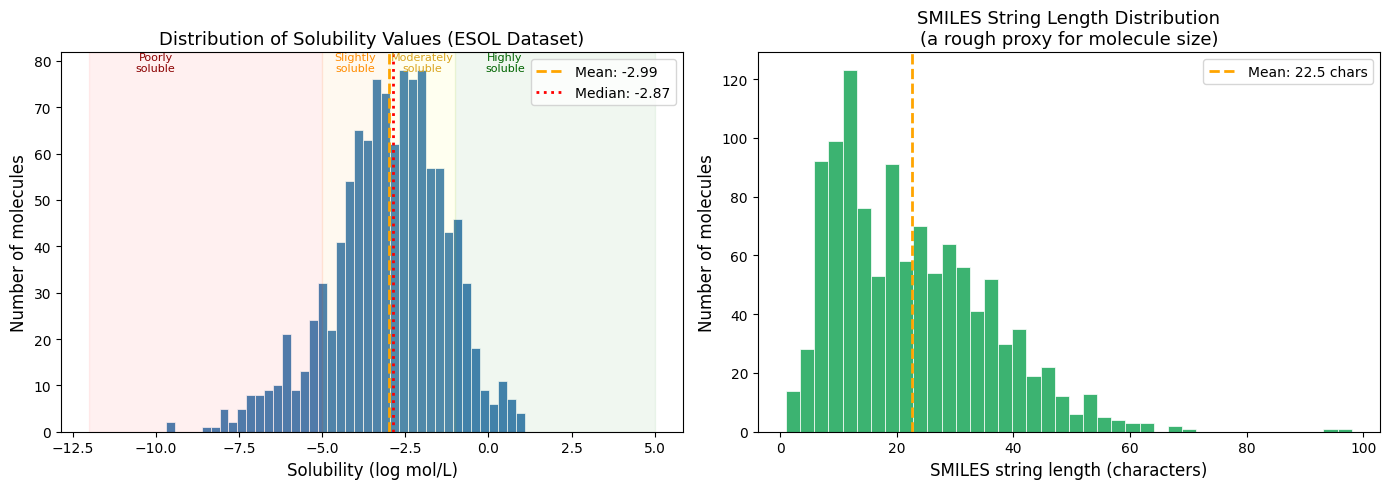


SMILES length stats:
  Min:    1 characters
  Max:    98 characters
  Median: 20 characters

  Longer SMILES usually = larger/more complex molecule = more atoms/bonds = larger graph


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Histogram of solubility values ---
ax1 = axes[0]
ax1.hist(df['solubility'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(df['solubility'].mean(), color='orange', linewidth=2, linestyle='--', label=f"Mean: {df['solubility'].mean():.2f}")
ax1.axvline(df['solubility'].median(), color='red', linewidth=2, linestyle=':', label=f"Median: {df['solubility'].median():.2f}")
ax1.set_xlabel("Solubility (log mol/L)", fontsize=12)
ax1.set_ylabel("Number of molecules", fontsize=12)
ax1.set_title("Distribution of Solubility Values (ESOL Dataset)", fontsize=13)
ax1.legend(fontsize=10)

# Add solubility category labels on x-axis
ax1.axvspan(-12, -5, alpha=0.06, color='red', label='Poorly soluble')
ax1.axvspan(-5, -3, alpha=0.06, color='orange')
ax1.axvspan(-3, -1, alpha=0.06, color='yellow')
ax1.axvspan(-1, 5, alpha=0.06, color='green')

# Annotation
y_top = ax1.get_ylim()[1]
ax1.text(-10, y_top * 0.95, 'Poorly\nsoluble', ha='center', fontsize=8, color='darkred')
ax1.text(-4, y_top * 0.95, 'Slightly\nsoluble', ha='center', fontsize=8, color='darkorange')
ax1.text(-2, y_top * 0.95, 'Moderately\nsoluble', ha='center', fontsize=8, color='goldenrod')
ax1.text(0.5, y_top * 0.95, 'Highly\nsoluble', ha='center', fontsize=8, color='darkgreen')

# --- Right: SMILES string length distribution ---
ax2 = axes[1]
smiles_lengths = df['smiles'].apply(len)
ax2.hist(smiles_lengths, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
ax2.axvline(smiles_lengths.mean(), color='orange', linewidth=2, linestyle='--', label=f"Mean: {smiles_lengths.mean():.1f} chars")
ax2.set_xlabel("SMILES string length (characters)", fontsize=12)
ax2.set_ylabel("Number of molecules", fontsize=12)
ax2.set_title("SMILES String Length Distribution\n(a rough proxy for molecule size)", fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('section1_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSMILES length stats:")
print(f"  Min:    {smiles_lengths.min()} characters")
print(f"  Max:    {smiles_lengths.max()} characters")
print(f"  Median: {smiles_lengths.median():.0f} characters")
print("\n  Longer SMILES usually = larger/more complex molecule = more atoms/bonds = larger graph")

## Step 1.9 — Visualize a few molecules

Let's draw the actual 2D structure of a few molecules to make the SMILES strings feel real. RDKit can generate 2D molecular diagrams.

This is purely visual — it helps build the intuition that a SMILES string is just a compact text encoding of a real molecular structure.

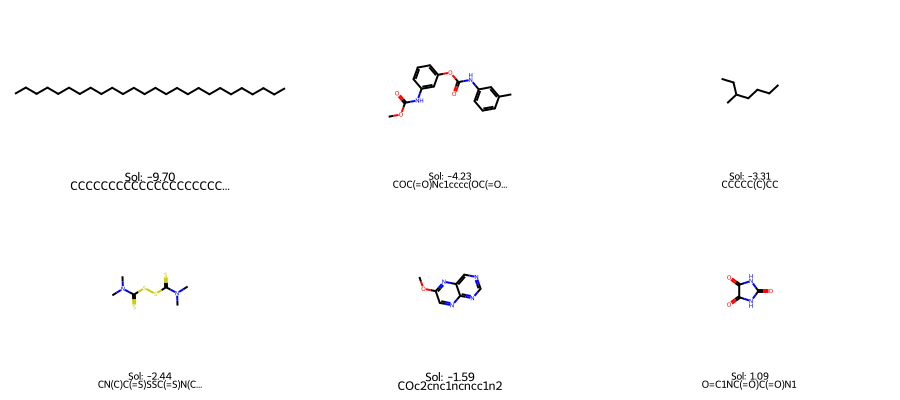


These 6 molecules span the full solubility range in the dataset.
Each is represented by a SMILES string. Each will become a graph.

Notice: smaller, simpler molecules tend to be more soluble.
Large, flat, aromatic molecules tend to be poorly soluble.


In [9]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display, Image as DisplayImage # Alias IPython.display.Image
import PIL.Image # Explicitly import PIL.Image
import io # Import io for BytesIO

# Pick 6 interesting molecules across the solubility range
df_sorted = df.sort_values('solubility').reset_index(drop=True)
indices = [0, len(df)//5, 2*len(df)//5, 3*len(df)//5, 4*len(df)//5, len(df)-1]
sample = df_sorted.iloc[indices]

# Draw molecules in a grid
mols = list(sample['mol'])
labels = [
    f"Sol: {row['solubility']:.2f}\n{row['smiles'][:20]}{'...' if len(row['smiles'])>20 else ''}"
    for _, row in sample.iterrows()
]

# Draw the image. This returns an IPython.display.Image object in Colab.
img_display = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 200),
    legends=labels
)

# Save and display
# Check if it's an IPython.display.Image and extract bytes for saving
if isinstance(img_display, DisplayImage):
    img_bytes = io.BytesIO(img_display.data)
    img_pil_for_save = PIL.Image.open(img_bytes)
    img_pil_for_save.save('section1_molecules.png')
else:
    # If for some reason it's already a PIL Image (e.g., in a different environment)
    img_display.save('section1_molecules.png')

display(img_display) # Display the original IPython.display.Image object

print("\nThese 6 molecules span the full solubility range in the dataset.")
print("Each is represented by a SMILES string. Each will become a graph.")
print("\nNotice: smaller, simpler molecules tend to be more soluble.")
print("Large, flat, aromatic molecules tend to be poorly soluble.")

---
## Section 1 Complete — What You Should Understand

Before moving on, make sure you can answer these questions:

1. **What dataset did we load?** ESOL — 1,128 organic molecules with measured aqueous solubility values.

2. **What is the target variable?** Solubility in log mol/L. Higher = more soluble in water.

3. **What is a SMILES string?** A text encoding of a molecule's structure. `CCO` is ethanol. `CC(=O)Oc1ccccc1C(=O)O` is aspirin.

4. **Why solubility?** It's a fundamental ADMET property. A drug that can't dissolve can't be absorbed.

5. **What does our data look like?** ~1,100 molecules. Solubility ranges from about -12 to +2 log mol/L. Roughly normally distributed. No significant missing values.

---

## What output you should see

After running all cells in Section 1, you should see:
- A printout confirming `~1128 molecules loaded` with no missing values
- Solubility statistics (mean around -3, std around 2)
- A few example SMILES strings with their solubility values
- A histogram showing the distribution of solubility values (roughly bell-shaped)
- A grid of 6 molecular structure diagrams

If molecules don't render visually, it's okay — the text output is what matters for now.

---

## What Section 2 will do

In Section 2, we take individual SMILES strings and convert them into **molecular graphs**.

You will:
- Parse a SMILES string into an RDKit molecule object
- Extract all atoms and bonds from the molecule
- Print the atom types, bond types, and connectivity
- Build the mental model: **atoms are nodes, bonds are edges**
- Understand what `edge_index` means in a graph

This is the step where we move from "chemistry" to "graph theory."

**When you're ready, move on to Section 2.**

---
# Section 2: Molecular Representation

**What we're doing:** Taking SMILES strings and converting them into explicit graph structures — lists of atoms (nodes) and bonds (edges).

**Why it matters for drug development:** A GNN can only operate on a graph. Before we can train anything, we need to convert every molecule into a format the network understands: a node feature matrix and an edge list. This step is the bridge between chemistry and machine learning.

**Input:** A SMILES string — e.g. `CC(=O)Oc1ccccc1C(=O)O` (aspirin)

**Output:** A graph description:
- A list of atoms with their properties (the nodes)
- A list of bonds connecting those atoms (the edges)

**The core idea:**

```
Molecule → Graph

  Atom  →  Node   (each atom is a point in the graph)
  Bond  →  Edge   (each bond is a connection between two nodes)
```

A graph is just a set of nodes and a set of edges. A molecule is already a graph — we just need to make that explicit.

**What can go wrong:** Some SMILES strings represent molecules with unusual valence (e.g., charged atoms, radicals). RDKit may sanitize or reject these. We already filtered them out in Section 1, so we're safe here.

**Simplification we're making:** We're ignoring 3D coordinates. Real molecules exist in 3D space, and 3D structure matters for binding. We're working with 2D graph topology only — atoms and which atoms they're bonded to. This is a meaningful simplification but a reasonable one for property prediction.

## Step 2.1 — Pick a few molecules to inspect

We'll work with 4 molecules chosen to show variety:
- A very simple molecule (few atoms)
- A molecule with a benzene ring (aromatic)
- A mid-size drug-like molecule
- Aspirin (familiar reference point)

For each one we'll manually walk through its graph structure.

In [10]:
# Four molecules to explore — chosen for variety
# We define them manually here so this section is self-contained
# (doesn't depend on which rows happened to load from the CSV)

example_molecules = [
    {"name": "Ethanol",        "smiles": "CCO"},
    {"name": "Benzene",        "smiles": "c1ccccc1"},
    {"name": "Aspirin",        "smiles": "CC(=O)Oc1ccccc1C(=O)O"},
    {"name": "Caffeine",       "smiles": "Cn1cnc2c1c(=O)n(c(=O)n2C)C"},
]

# Parse each SMILES into an RDKit molecule object
for entry in example_molecules:
    mol = Chem.MolFromSmiles(entry['smiles'])
    entry['mol'] = mol

print("Molecules loaded:")
for e in example_molecules:
    m = e['mol']
    print(f"  {e['name']:15s}  SMILES: {e['smiles']}")
    print(f"  {'':15s}  Atoms: {m.GetNumAtoms()}  |  Bonds: {m.GetNumBonds()}")
    print()

Molecules loaded:
  Ethanol          SMILES: CCO
                   Atoms: 3  |  Bonds: 2

  Benzene          SMILES: c1ccccc1
                   Atoms: 6  |  Bonds: 6

  Aspirin          SMILES: CC(=O)Oc1ccccc1C(=O)O
                   Atoms: 13  |  Bonds: 13

  Caffeine         SMILES: Cn1cnc2c1c(=O)n(c(=O)n2C)C
                   Atoms: 14  |  Bonds: 15



## Step 2.2 — Atoms as nodes

In RDKit, once you have a molecule object you can iterate over its atoms.

Each atom has properties we can read:
- **Symbol** — the element (C, N, O, ...)
- **Atomic number** — integer ID for the element (Carbon=6, Nitrogen=7, Oxygen=8, ...)
- **Degree** — how many bonds this atom has to other heavy atoms
- **Formal charge** — whether the atom carries a positive or negative charge
- **Is aromatic** — whether the atom is part of an aromatic ring like benzene

These properties will become the **node features** in our GNN — the numbers we feed into the network for each atom.

For now, just read them. We'll convert them into feature vectors in Section 3.

In [11]:
# Print every atom in each molecule with its key properties

for entry in example_molecules:
    mol = entry['mol']
    print("=" * 55)
    print(f"  {entry['name']}  |  SMILES: {entry['smiles']}")
    print(f"  {mol.GetNumAtoms()} atoms (nodes)  |  {mol.GetNumBonds()} bonds (edges)")
    print("=" * 55)
    print(f"  {'Node':>5}  {'Symbol':>6}  {'AtomicNum':>9}  {'Degree':>6}  {'Charge':>6}  {'Aromatic':>8}")
    print(f"  {'-'*5}  {'-'*6}  {'-'*9}  {'-'*6}  {'-'*6}  {'-'*8}")

    for atom in mol.GetAtoms():
        print(f"  {atom.GetIdx():>5}  "
              f"{atom.GetSymbol():>6}  "
              f"{atom.GetAtomicNum():>9}  "
              f"{atom.GetDegree():>6}  "
              f"{atom.GetFormalCharge():>6}  "
              f"{str(atom.GetIsAromatic()):>8}")
    print()

print("Key observations:")
print("  - Each atom has an integer index (Node 0, 1, 2, ...) — this is its ID in the graph")
print("  - Benzene's carbons all show Aromatic=True — they're in a ring with delocalized electrons")
print("  - Degree = number of heavy-atom bonds — Hydrogen bonds are implicit in SMILES")
print("  - These properties are what we'll turn into feature vectors in Section 3")

  Ethanol  |  SMILES: CCO
  3 atoms (nodes)  |  2 bonds (edges)
   Node  Symbol  AtomicNum  Degree  Charge  Aromatic
  -----  ------  ---------  ------  ------  --------
      0       C          6       1       0     False
      1       C          6       2       0     False
      2       O          8       1       0     False

  Benzene  |  SMILES: c1ccccc1
  6 atoms (nodes)  |  6 bonds (edges)
   Node  Symbol  AtomicNum  Degree  Charge  Aromatic
  -----  ------  ---------  ------  ------  --------
      0       C          6       2       0      True
      1       C          6       2       0      True
      2       C          6       2       0      True
      3       C          6       2       0      True
      4       C          6       2       0      True
      5       C          6       2       0      True

  Aspirin  |  SMILES: CC(=O)Oc1ccccc1C(=O)O
  13 atoms (nodes)  |  13 bonds (edges)
   Node  Symbol  AtomicNum  Degree  Charge  Aromatic
  -----  ------  ---------  ------  ---

## Step 2.3 — Bonds as edges

Each bond connects two atoms by their index. That's all an edge is in a graph — a pair of node IDs.

Bonds also have a **type**:
- **SINGLE** — one pair of shared electrons (e.g. C-C in ethane)
- **DOUBLE** — two pairs of shared electrons (e.g. C=O in aspirin's carbonyl)
- **TRIPLE** — three pairs (rare in drug-like molecules)
- **AROMATIC** — delocalized electrons in a ring (e.g. benzene)

Bond type tells you something about the electron density and geometry around those atoms — both of which affect how a molecule behaves chemically.

In a GNN, bonds can become **edge features** (optional). For now, we print them to build intuition.

In [12]:
# Print every bond in each molecule

for entry in example_molecules:
    mol = entry['mol']
    print("=" * 45)
    print(f"  {entry['name']}  — Bonds (Edges)")
    print("=" * 45)
    print(f"  {'Bond':>5}  {'Atom_i':>7}  {'Atom_j':>7}  {'Type':>10}")
    print(f"  {'-'*5}  {'-'*7}  {'-'*7}  {'-'*10}")

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        btype = bond.GetBondTypeAsDouble()  # 1.0=single, 1.5=aromatic, 2.0=double
        bname = str(bond.GetBondType()).split('.')[-1]  # e.g. 'SINGLE'
        print(f"  {bond.GetIdx():>5}  "
              f"{i:>7}  "
              f"{j:>7}  "
              f"{bname:>10}")
    print()

  Ethanol  — Bonds (Edges)
   Bond   Atom_i   Atom_j        Type
  -----  -------  -------  ----------
      0        0        1      SINGLE
      1        1        2      SINGLE

  Benzene  — Bonds (Edges)
   Bond   Atom_i   Atom_j        Type
  -----  -------  -------  ----------
      0        0        1    AROMATIC
      1        1        2    AROMATIC
      2        2        3    AROMATIC
      3        3        4    AROMATIC
      4        4        5    AROMATIC
      5        5        0    AROMATIC

  Aspirin  — Bonds (Edges)
   Bond   Atom_i   Atom_j        Type
  -----  -------  -------  ----------
      0        0        1      SINGLE
      1        1        2      DOUBLE
      2        1        3      SINGLE
      3        3        4      SINGLE
      4        4        5    AROMATIC
      5        5        6    AROMATIC
      6        6        7    AROMATIC
      7        7        8    AROMATIC
      8        8        9    AROMATIC
      9        9       10      SINGLE
     

## Step 2.4 — Building the edge index

In PyTorch Geometric (which we'll use in Section 3+), the graph connectivity is stored as an **edge_index** tensor.

`edge_index` has shape `[2, num_edges]`.

- Row 0: the **source** atom index for each edge
- Row 1: the **destination** atom index for each edge

**Important:** graphs in GNNs are treated as **undirected but stored as directed**. Every bond A→B also becomes B→A. So if a molecule has 5 bonds, the edge_index has 10 columns.

Why? During message passing, atom A needs to receive information from atom B, AND atom B needs to receive information from atom A. Storing both directions makes that easy.

Example for ethanol (CCO — 3 atoms, 2 bonds):
```
Bond 0-1 and bond 1-2

edge_index = [[0, 1, 1, 2],
              [1, 0, 2, 1]]

Shape: [2, 4]  ← 2 bonds × 2 directions
```

In [13]:
import torch

def mol_to_edge_index(mol):
    """
    Convert an RDKit molecule's bonds into a PyTorch edge_index tensor.
    Each bond A-B becomes two directed edges: A->B and B->A.
    Returns a LongTensor of shape [2, num_bonds * 2].
    """
    src = []
    dst = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        src += [i, j]  # both directions
        dst += [j, i]
    return torch.tensor([src, dst], dtype=torch.long)


print("Edge index for each molecule:")
print()

for entry in example_molecules:
    mol = entry['mol']
    edge_index = mol_to_edge_index(mol)

    print(f"  {entry['name']}")
    print(f"    Atoms (nodes):        {mol.GetNumAtoms()}")
    print(f"    Bonds:                {mol.GetNumBonds()}")
    print(f"    edge_index shape:     {list(edge_index.shape)}   ← [2, bonds×2]")
    print(f"    edge_index row 0:     {edge_index[0].tolist()}  (source atoms)")
    print(f"    edge_index row 1:     {edge_index[1].tolist()}  (destination atoms)")
    print()

Edge index for each molecule:

  Ethanol
    Atoms (nodes):        3
    Bonds:                2
    edge_index shape:     [2, 4]   ← [2, bonds×2]
    edge_index row 0:     [0, 1, 1, 2]  (source atoms)
    edge_index row 1:     [1, 0, 2, 1]  (destination atoms)

  Benzene
    Atoms (nodes):        6
    Bonds:                6
    edge_index shape:     [2, 12]   ← [2, bonds×2]
    edge_index row 0:     [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 0]  (source atoms)
    edge_index row 1:     [1, 0, 2, 1, 3, 2, 4, 3, 5, 4, 0, 5]  (destination atoms)

  Aspirin
    Atoms (nodes):        13
    Bonds:                13
    edge_index shape:     [2, 26]   ← [2, bonds×2]
    edge_index row 0:     [0, 1, 1, 2, 1, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 10, 12, 9, 4]  (source atoms)
    edge_index row 1:     [1, 0, 2, 1, 3, 1, 4, 3, 5, 4, 6, 5, 7, 6, 8, 7, 9, 8, 10, 9, 11, 10, 12, 10, 4, 9]  (destination atoms)

  Caffeine
    Atoms (nodes):        14
    Bonds:                15
    edge_i

## Step 2.5 — Visualize the graph structure

Let's draw the graph explicitly — nodes as circles, edges as lines — using NetworkX.

This makes the graph structure visible alongside the 2D molecular diagram. The two images represent the same thing: one is drawn as a chemist would draw it, the other as a graph theorist would.

**NetworkX** is a standard Python library for working with graphs. We won't use it in the GNN itself — PyTorch Geometric handles graphs differently — but it's useful for visualization.

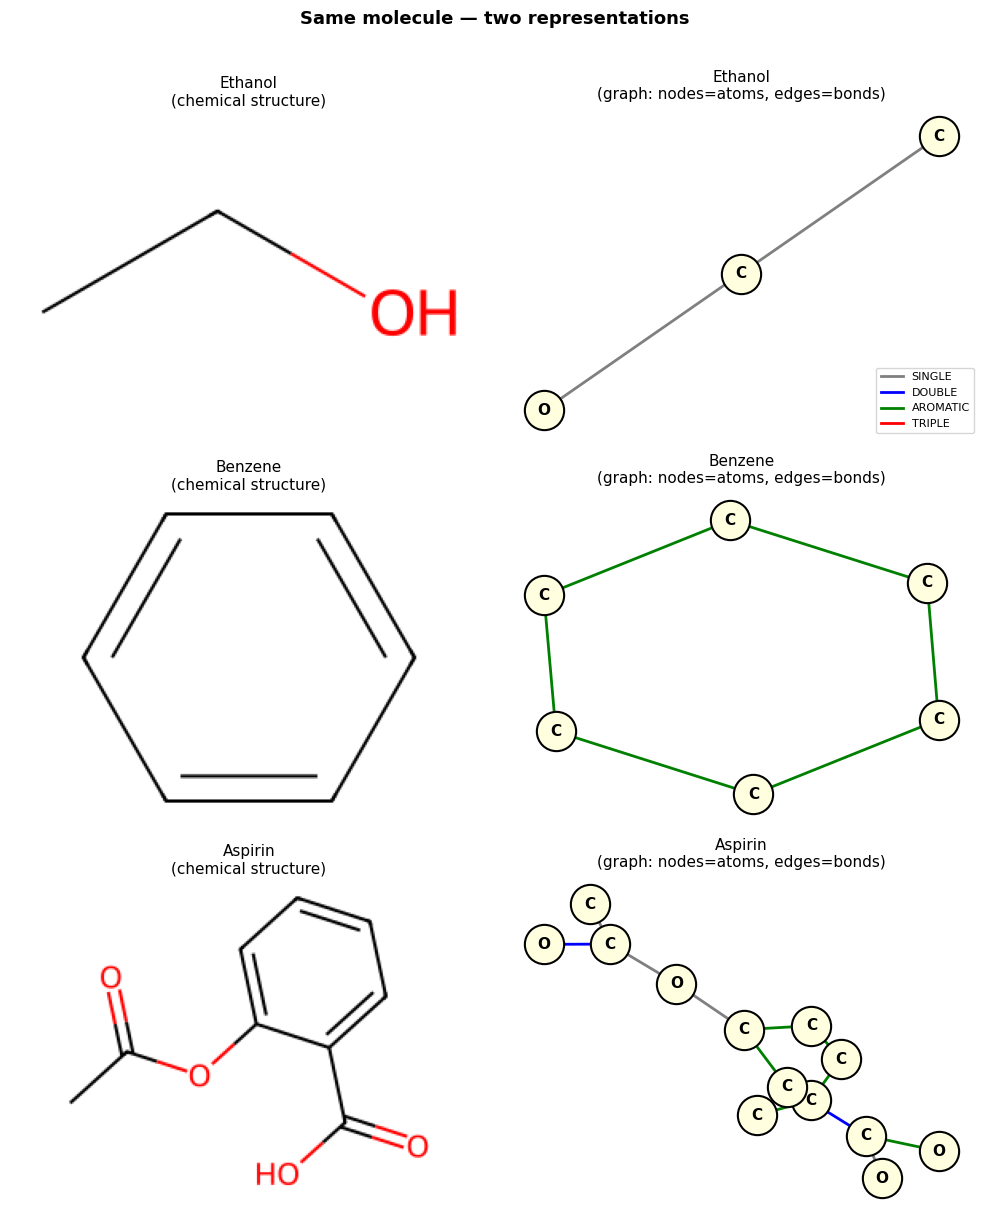

Left = how a chemist draws a molecule
Right = how a GNN sees it: labeled nodes connected by edges
They contain exactly the same information.


In [14]:
import networkx as nx
from rdkit.Chem import Draw

# Visualize 3 molecules: molecular diagram (RDKit) alongside graph diagram (NetworkX)
molecules_to_plot = example_molecules[:3]  # ethanol, benzene, aspirin

fig, axes = plt.subplots(len(molecules_to_plot), 2, figsize=(10, 4 * len(molecules_to_plot)))

bond_type_colors = {
    'SINGLE':   'gray',
    'DOUBLE':   'blue',
    'AROMATIC': 'green',
    'TRIPLE':   'red',
}

for row_idx, entry in enumerate(molecules_to_plot):
    mol  = entry['mol']
    name = entry['name']

    # --- Left: RDKit 2D molecular diagram ---
    ax_mol = axes[row_idx][0]
    img = Draw.MolToImage(mol, size=(300, 200))
    ax_mol.imshow(img)
    ax_mol.axis('off')
    ax_mol.set_title(f"{name}\n(chemical structure)", fontsize=11)

    # --- Right: NetworkX graph ---
    ax_graph = axes[row_idx][1]
    G = nx.Graph()

    # Add nodes with element label
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), label=atom.GetSymbol())

    # Add edges with bond type
    edge_colors = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bname = str(bond.GetBondType()).split('.')[-1]
        G.add_edge(i, j, bond_type=bname)
        edge_colors.append(bond_type_colors.get(bname, 'black'))

    pos    = nx.spring_layout(G, seed=42)
    labels = nx.get_node_attributes(G, 'label')

    nx.draw_networkx_nodes(G, pos, ax=ax_graph, node_color='lightyellow',
                           node_size=800, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax_graph, font_size=11, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax_graph, edge_color=edge_colors, width=2)
    ax_graph.set_title(f"{name}\n(graph: nodes=atoms, edges=bonds)", fontsize=11)
    ax_graph.axis('off')

    # Legend for first row only
    if row_idx == 0:
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0],[0], color=c, linewidth=2, label=t)
                           for t, c in bond_type_colors.items()]
        ax_graph.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.suptitle("Same molecule — two representations", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('section2_graphs.png', dpi=120, bbox_inches='tight')
plt.show()

print("Left = how a chemist draws a molecule")
print("Right = how a GNN sees it: labeled nodes connected by edges")
print("They contain exactly the same information.")

---
## Section 2 Complete — What You Should Understand

1. **A molecule is a graph.** Atoms are nodes. Bonds are edges. This isn't a metaphor — it's a direct mapping.

2. **Each atom has properties** — symbol, atomic number, degree, charge, aromaticity. These will become node feature vectors in Section 3.

3. **Each bond has a type** — single, double, aromatic. These can optionally become edge features.

4. **`edge_index` shape is `[2, num_bonds * 2]`** — every bond is stored twice (both directions) so message passing can flow both ways.

5. **The graph representation discards 3D coordinates** — we're working with topology (connectivity) only. This is a simplification that works well for property prediction.

---

## What output you should see

- A table of atoms for each molecule with symbol, atomic number, degree, charge, aromaticity
- A table of bonds with source/destination atom indices and bond type
- `edge_index` tensors printed for each molecule — check that the shape is `[2, num_bonds * 2]`
- Side-by-side plots: RDKit 2D structure (left) and NetworkX graph (right)

For ethanol (CCO):
- 3 atoms: C(0), C(1), O(2)
- 2 bonds → edge_index shape `[2, 4]`
- edge_index: `[[0, 1, 1, 2], [1, 0, 2, 1]]`

---

## What Section 3 will do

Now that we can see atoms and bonds, Section 3 turns them into **numbers**.

Each atom becomes a **feature vector** — a fixed-length list of numbers encoding its properties. For example:
```
Carbon atom → [6, 2, 0, 0, 0, 1]  ← [atomic_num, degree, charge, ...]
```
Stack all atom vectors into a matrix `x` of shape `[num_atoms, num_features]`.
Combine with `edge_index` and the solubility label `y`, and you have one complete PyTorch Geometric `Data` object — a single training example for the GNN.

**When you're ready, move on to Section 3.**

---
# Section 3: Feature Engineering

**What we're doing:** Converting atom properties into numbers that a neural network can actually process.

**Why it matters:** A GNN doesn't understand 'Carbon' or 'aromatic'. It only understands numbers. Feature engineering is the step where chemistry becomes math.

**Input:** An RDKit molecule object (from Section 2)

**Output:** Three tensors that together describe one molecule to the GNN:
- `x` — node feature matrix, shape `[num_atoms, num_features]`
- `edge_index` — graph connectivity, shape `[2, num_bonds * 2]`
- `y` — target value (solubility), shape `[1]`

**Simplification we're making:** We're only using atom-level features (node features). We're ignoring bond features (edge features) for now. This is a common starting point — bond features can be added later and sometimes improve performance.

**What can go wrong:** If we encode features inconsistently (e.g. different feature lengths for different molecules), the GNN will crash. Every molecule must produce an `x` matrix with the same number of columns.

## Step 3.0 — Install PyTorch Geometric

PyTorch Geometric (PyG) is the standard library for graph neural networks in PyTorch. It handles:
- The `Data` object that stores a single graph (x, edge_index, y)
- The `DataLoader` that batches multiple graphs for training
- Built-in GNN layers (GCNConv, GINConv, etc.) that we'll use in Sections 6 and 9

Installation in Colab is straightforward with recent versions of PyG (2.0+).

> **If this cell throws an error about torch version mismatches:** Restart the Colab runtime (`Runtime → Restart runtime`) and re-run from the top. Colab sometimes needs a fresh session after installing new packages.

In [15]:
import torch
print(f"PyTorch version: {torch.__version__}")

# Install PyTorch Geometric
# PyG 2.0+ no longer requires separate torch-scatter/torch-sparse installs
!pip install torch-geometric --quiet

# Verify the install
import torch_geometric
print(f"PyTorch Geometric version: {torch_geometric.__version__}")
print("Installation successful.")

PyTorch version: 2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.9 MB/s eta 0:00:00
PyTorch Geometric version: 2.7.0
Installation successful.


## Step 3.1 — Design atom features

We need to turn each atom into a fixed-length vector of numbers.

Here are the features we'll use and why each one matters chemically:

| Feature | What it is | Why it matters |
|---|---|---|
| **Atomic number** | Integer ID of the element (C=6, N=7, O=8...) | Different elements have different electronegativity, size, and bonding behavior |
| **Degree** | Number of bonds to other heavy atoms | Captures local connectivity — a carbon with 4 bonds behaves differently than one with 1 |
| **Formal charge** | Net electric charge on the atom | Charged atoms dramatically change solubility and reactivity |
| **Num. hydrogens** | Number of attached hydrogens | Hydrogen bond donors affect solubility (as you noted in Section 1) |
| **Is aromatic** | Whether the atom is in an aromatic ring | Aromatic atoms are hydrophobic and rigid — directly connected to your benzene ring note |
| **Hybridization** | sp, sp2, or sp3 orbital geometry | Determines molecular geometry and electron distribution |

**Why not just use the raw numbers?**

For features like atomic number, we use **one-hot encoding** instead of the raw integer. Here's why:

If we feed atomic numbers as raw integers, the model sees Carbon (6) as 'twice as much' as Lithium (3). That's meaningless — elements aren't on a linear scale. One-hot encoding treats each element as a separate category with no implied ordering.

For example, with elements [C, N, O, F, Other]:
```
Carbon   → [1, 0, 0, 0, 0]
Nitrogen → [0, 1, 0, 0, 0]
Oxygen   → [0, 0, 1, 0, 0]
Fluorine → [0, 0, 0, 1, 0]
Sulfur   → [0, 0, 0, 0, 1]  ← 'Other'
```

We'll one-hot encode atomic number, degree, and hybridization. We'll keep charge and hydrogen count as raw integers since they have a meaningful scale.

In [16]:
import torch
from rdkit.Chem import rdchem

# -------------------------------------------------------
# Define the categories for one-hot encoding
# -------------------------------------------------------

# Most drug-like molecules are made of these elements.
# Anything outside this list maps to 'other' (last position).
ATOM_TYPES    = [6, 7, 8, 9, 15, 16, 17, 35, 53]  # C, N, O, F, P, S, Cl, Br, I

# Atoms in drug-like molecules rarely have degree > 6
DEGREE_LIST   = [0, 1, 2, 3, 4, 5, 6]

# The three most common hybridization states in organic molecules
HYBRID_LIST   = [
    rdchem.HybridizationType.SP,
    rdchem.HybridizationType.SP2,
    rdchem.HybridizationType.SP3,
]

def one_hot(value, categories):
    """
    Returns a list of 0s and 1s.
    Length = len(categories) + 1 (the last slot = 'other/unknown').
    """
    vec = [0] * (len(categories) + 1)
    if value in categories:
        vec[categories.index(value)] = 1
    else:
        vec[-1] = 1  # 'other' bucket
    return vec


def atom_to_feature_vector(atom):
    """
    Convert a single RDKit atom into a fixed-length feature vector.

    Returns a flat Python list of numbers.
    """
    features = (
        one_hot(atom.GetAtomicNum(),       ATOM_TYPES)   +  # 10 values (9 elements + other)
        one_hot(atom.GetDegree(),          DEGREE_LIST)  +  #  8 values (0-6 + other)
        one_hot(atom.GetHybridization(),   HYBRID_LIST)  +  #  4 values (sp/sp2/sp3 + other)
        [atom.GetFormalCharge()]                         +  #  1 value  (raw integer)
        [atom.GetTotalNumHs()]                           +  #  1 value  (raw integer)
        [int(atom.GetIsAromatic())]                         #  1 value  (0 or 1)
    )
    return features


# Calculate total feature vector length
FEATURE_DIM = len(ATOM_TYPES)+1 + len(DEGREE_LIST)+1 + len(HYBRID_LIST)+1 + 3

print(f"Feature vector breakdown:")
print(f"  Atomic number (one-hot): {len(ATOM_TYPES)+1:>3} values")
print(f"  Degree        (one-hot): {len(DEGREE_LIST)+1:>3} values")
print(f"  Hybridization (one-hot): {len(HYBRID_LIST)+1:>3} values")
print(f"  Formal charge  (scalar): {'1':>3} value")
print(f"  Num. hydrogens (scalar): {'1':>3} value")
print(f"  Is aromatic    (binary): {'1':>3} value")
print(f"  {'─'*30}")
print(f"  Total feature dim:       {FEATURE_DIM:>3} values per atom")

Feature vector breakdown:
  Atomic number (one-hot):  10 values
  Degree        (one-hot):   8 values
  Hybridization (one-hot):   4 values
  Formal charge  (scalar):   1 value
  Num. hydrogens (scalar):   1 value
  Is aromatic    (binary):   1 value
  ──────────────────────────────
  Total feature dim:        25 values per atom


## Step 3.2 — Build the node feature matrix `x`

We now apply `atom_to_feature_vector` to every atom in a molecule and stack the results into a 2D matrix.

For a molecule with `N` atoms:
```
atom 0 → [f0, f1, f2, ..., f24]   ← one row
atom 1 → [f0, f1, f2, ..., f24]
atom 2 → [f0, f1, f2, ..., f24]
...
atom N → [f0, f1, f2, ..., f24]

x shape: [N, 25]   ← N rows (atoms), 25 columns (features)
```

This matrix `x` is what gets fed into the first GNN layer. Each row is one atom's starting representation before any message passing happens.

In [17]:
def mol_to_node_features(mol):
    """
    Build the node feature matrix x for a molecule.
    Returns a FloatTensor of shape [num_atoms, FEATURE_DIM].
    """
    feature_list = [atom_to_feature_vector(atom) for atom in mol.GetAtoms()]
    return torch.tensor(feature_list, dtype=torch.float)


# --- Inspect features for our 4 example molecules ---
print("Node feature matrix x for each example molecule:")
print()

for entry in example_molecules:
    mol = entry['mol']
    x = mol_to_node_features(mol)
    print(f"  {entry['name']}")
    print(f"    x.shape = {list(x.shape)}   ← [{mol.GetNumAtoms()} atoms  x  {FEATURE_DIM} features]")

print()
print("─" * 55)
print("Detailed view: Ethanol atom features")
print("─" * 55)

ethanol_mol = example_molecules[0]['mol']
x_ethanol = mol_to_node_features(ethanol_mol)

for i, atom in enumerate(ethanol_mol.GetAtoms()):
    vec = x_ethanol[i].tolist()
    print(f"  Atom {i} ({atom.GetSymbol()})")
    print(f"    Full vector: {[int(v) for v in vec]}")
    # Decode the meaningful parts
    atomic_oh  = vec[:len(ATOM_TYPES)+1]
    degree_oh  = vec[len(ATOM_TYPES)+1 : len(ATOM_TYPES)+1+len(DEGREE_LIST)+1]
    hybrid_oh  = vec[len(ATOM_TYPES)+1+len(DEGREE_LIST)+1 : -3]
    charge     = int(vec[-3])
    num_hs     = int(vec[-2])
    aromatic   = int(vec[-1])
    print(f"    Atomic num one-hot : {[int(v) for v in atomic_oh]}  (C=pos 0)")
    print(f"    Degree one-hot     : {[int(v) for v in degree_oh]}")
    print(f"    Hybridization      : {[int(v) for v in hybrid_oh]}")
    print(f"    Formal charge      : {charge}")
    print(f"    Num hydrogens      : {num_hs}")
    print(f"    Is aromatic        : {aromatic}")
    print()

Node feature matrix x for each example molecule:

  Ethanol
    x.shape = [3, 25]   ← [3 atoms  x  25 features]
  Benzene
    x.shape = [6, 25]   ← [6 atoms  x  25 features]
  Aspirin
    x.shape = [13, 25]   ← [13 atoms  x  25 features]
  Caffeine
    x.shape = [14, 25]   ← [14 atoms  x  25 features]

───────────────────────────────────────────────────────
Detailed view: Ethanol atom features
───────────────────────────────────────────────────────
  Atom 0 (C)
    Full vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 3, 0]
    Atomic num one-hot : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (C=pos 0)
    Degree one-hot     : [0, 1, 0, 0, 0, 0, 0, 0]
    Hybridization      : [0, 0, 1, 0]
    Formal charge      : 0
    Num hydrogens      : 3
    Is aromatic        : 0

  Atom 1 (C)
    Full vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]
    Atomic num one-hot : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  (C=pos 0)
    Degree one-hot     : [0, 0,

## Step 3.3 — Build a PyTorch Geometric `Data` object

A PyG `Data` object is a container that holds everything about one molecule:

```python
Data(
    x          = node feature matrix,   shape [num_atoms, num_features]
    edge_index = graph connectivity,    shape [2, num_bonds * 2]
    y          = target value,          shape [1]
)
```

This is one training example. The DataLoader in Section 7 will combine many of these into a batch.

We reuse `mol_to_edge_index` from Section 2.

In [18]:
from torch_geometric.data import Data

def mol_to_data(mol, y_value):
    """
    Convert an RDKit molecule + a target value into a PyG Data object.

    Args:
        mol:     RDKit molecule object
        y_value: float — the property we want to predict (e.g. solubility)

    Returns:
        PyG Data object with x, edge_index, y
    """
    x          = mol_to_node_features(mol)
    edge_index = mol_to_edge_index(mol)
    y          = torch.tensor([y_value], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, y=y)


# --- Inspect one Data object ---
aspirin = example_molecules[2]  # aspirin
aspirin_solubility = df[df['smiles'] == aspirin['smiles']]['solubility'].values
y_val = float(aspirin_solubility[0]) if len(aspirin_solubility) > 0 else -1.68

data = mol_to_data(aspirin['mol'], y_val)

print("PyG Data object for Aspirin:")
print(f"  {data}")
print()
print(f"  x.shape          = {list(data.x.shape)}")
print(f"  edge_index.shape = {list(data.edge_index.shape)}")
print(f"  y.shape          = {list(data.y.shape)}")
print(f"  y value          = {data.y.item():.4f}  (solubility in log mol/L)")
print()
print("Interpretation:")
print(f"  x: {data.x.shape[0]} atoms, each described by {data.x.shape[1]} features")
print(f"  edge_index: {data.edge_index.shape[1]} directed edges ({data.edge_index.shape[1]//2} bonds × 2 directions)")
print(f"  y: a single number — the solubility value we want to predict")

PyG Data object for Aspirin:
  Data(x=[13, 25], edge_index=[2, 26], y=[1])

  x.shape          = [13, 25]
  edge_index.shape = [2, 26]
  y.shape          = [1]
  y value          = -1.6800  (solubility in log mol/L)

Interpretation:
  x: 13 atoms, each described by 25 features
  edge_index: 26 directed edges (13 bonds × 2 directions)
  y: a single number — the solubility value we want to predict


## Step 3.4 — Convert the entire dataset

Now we apply `mol_to_data` to every molecule in the ESOL dataset.

The result is a Python list of `Data` objects — one per molecule. This is our full processed dataset, ready for splitting and training.

In [19]:
print("Converting all molecules to PyG Data objects...")

dataset = []
failed  = 0

for _, row in df.iterrows():
    mol = row['mol']
    if mol is None:
        failed += 1
        continue
    data = mol_to_data(mol, row['solubility'])
    dataset.append(data)

print(f"Done.")
print(f"  Total Data objects: {len(dataset)}")
print(f"  Failed conversions: {failed}")
print()

# Sanity check: verify all x matrices have the same number of features
feature_dims = set(d.x.shape[1] for d in dataset)
print(f"Feature dimensions found: {feature_dims}")
if len(feature_dims) == 1:
    print(f"  ✓ Consistent — all molecules have {list(feature_dims)[0]} features per atom")
else:
    print(f"  ✗ Inconsistent feature dimensions — something went wrong in feature engineering")

print()

# Summary statistics about the dataset graphs
num_atoms_list = [d.x.shape[0] for d in dataset]
num_edges_list = [d.edge_index.shape[1] for d in dataset]

print("Graph size statistics:")
print(f"  Atoms per molecule — min: {min(num_atoms_list)}, max: {max(num_atoms_list)}, avg: {sum(num_atoms_list)/len(num_atoms_list):.1f}")
print(f"  Edges per molecule — min: {min(num_edges_list)}, max: {max(num_edges_list)}, avg: {sum(num_edges_list)/len(num_edges_list):.1f}")
print()
print("This is a variable-size graph dataset — every molecule has a different number")
print("of atoms and bonds. The GNN handles this naturally. A standard MLP cannot.")

Converting all molecules to PyG Data objects...
Done.
  Total Data objects: 1128
  Failed conversions: 0

Feature dimensions found: {25}
  ✓ Consistent — all molecules have 25 features per atom

Graph size statistics:
  Atoms per molecule — min: 1, max: 55, avg: 13.3
  Edges per molecule — min: 0, max: 124, avg: 27.4

This is a variable-size graph dataset — every molecule has a different number
of atoms and bonds. The GNN handles this naturally. A standard MLP cannot.


---
## Section 3 Complete — What You Should Understand

1. **Each atom becomes a 25-number vector.** Those numbers encode element type, connectivity, charge, hydrogens, aromaticity, and orbital geometry.

2. **One-hot encoding matters.** We don't feed atomic number as a raw integer. Carbon is not 'worth 6'. It's a category, and we encode it as such.

3. **`x` shape is `[num_atoms, 25]`.** Every molecule has a different `num_atoms`, but always exactly 25 features per atom. This consistency is what the GNN requires.

4. **A PyG `Data` object = one molecule.** It holds `x`, `edge_index`, and `y` together. The entire dataset is a list of these.

5. **GNNs handle variable-size graphs naturally.** Aspirin has 13 atoms, caffeine has 14. A standard neural network would choke on this. GNNs don't care — they process whatever graph they're given.

---

## What output you should see

- Feature vector breakdown: 10 + 8 + 4 + 1 + 1 + 1 = **25 total features**
- Ethanol: `x.shape = [3, 25]` (3 atoms × 25 features)
- Benzene: `x.shape = [6, 25]`
- Aspirin: `x.shape = [13, 25]`
- Full dataset: **1128 Data objects**, all with consistent 25-feature vectors
- A message confirming `✓ Consistent — all molecules have 25 features per atom`

---

## What Section 4 will do

We split the dataset into train / validation / test sets.

We'll start with a random split, then discuss why that can be misleading for molecular datasets (molecules with similar scaffolds end up in both train and test, making performance look better than it really is). We'll explain scaffold splitting as the more honest alternative.

**When you're ready, move on to Section 4.**

---
# Section 4: Train / Validation / Test Split

**What we're doing:** Dividing the dataset into three non-overlapping subsets so we can train the model, tune it, and evaluate it honestly.

**Why it matters:** If we train and evaluate on the same molecules, the model can simply memorize the answers. We need held-out data the model has never seen to measure how well it actually generalizes.

**The three splits:**
| Split | Purpose | Typical size |
|---|---|---|
| **Train** | The model learns from this | 80% |
| **Validation** | Used during training to tune hyperparameters and catch overfitting | 10% |
| **Test** | Touched only once at the very end to report final performance | 10% |

The test set is sacred — you look at it once, at the end, and report whatever number you get. If you keep peeking at it to improve the model, you're overfitting to the test set without realizing it.

**What can go wrong:** Random splitting of molecular datasets is convenient but optimistic. We explain why below.

## Step 4.1 — Random split

The simplest approach: shuffle the dataset and cut it at fixed percentages.

We use `train_test_split` from scikit-learn twice — first to carve off the test set, then to split the remainder into train and validation.

In [21]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42  # fix the seed so results are reproducible

# Step 1: split off 10% as test
train_val, test_data = train_test_split(
    dataset,
    test_size=0.10,
    random_state=RANDOM_SEED
)

# Step 2: split the remaining 90% into 80% train and 10% val
# (10% of 90% ≈ 11% overall, close enough for our purposes)
train_data, val_data = train_test_split(
    train_val,
    test_size=0.111,
    random_state=RANDOM_SEED
)

print("Split type: RANDOM")
print(f"  Train:      {len(train_data):>5} molecules  ({100*len(train_data)/len(dataset):.1f}%)")
print(f"  Validation: {len(val_data):>5} molecules  ({100*len(val_data)/len(dataset):.1f}%)")
print(f"  Test:       {len(test_data):>5} molecules  ({100*len(test_data)/len(dataset):.1f}%)")
print(f"  Total:      {len(train_data)+len(val_data)+len(test_data):>5} molecules")
print()

# Check that solubility distributions are similar across splits
# (they should be, with random split)
train_y = [d.y.item() for d in train_data]
val_y   = [d.y.item() for d in val_data]
test_y  = [d.y.item() for d in test_data]

import numpy as np
print("Solubility distribution check (should be similar across splits):")
print(f"  {'Split':<12} {'Mean':>6}  {'Std':>5}  {'Min':>6}  {'Max':>6}")
print(f"  {'─'*12} {'─'*6}  {'─'*5}  {'─'*6}  {'─'*6}")
for name, vals in [('Train', train_y), ('Validation', val_y), ('Test', test_y)]:
    arr = np.array(vals)
    print(f"  {name:<12} {arr.mean():>6.2f}  {arr.std():>5.2f}  {arr.min():>6.2f}  {arr.max():>6.2f}")

Split type: RANDOM
  Train:        902 molecules  (80.0%)
  Validation:   113 molecules  (10.0%)
  Test:         113 molecules  (10.0%)
  Total:       1128 molecules

Solubility distribution check (should be similar across splits):
  Split          Mean    Std     Min     Max
  ──────────── ──────  ─────  ──────  ──────
  Train         -2.98   1.63   -9.59    1.09
  Validation    -2.94   1.81   -8.47    0.92
  Test          -3.12   1.91   -9.70    0.68


## Step 4.2 — Why random split can be misleading

Random split works well for image or text datasets, where samples are usually independent. Molecules are different.

**The problem: similar molecules end up in both train and test.**

Many drug datasets contain families of related molecules — for example, 20 variations of the same benzene scaffold with different side chains. With random split, some variants land in train and similar ones land in test. The model hasn't truly generalized; it has essentially memorized a template and filled in the blanks.

This makes test performance look better than it really is. In real drug discovery, you're trying to predict properties of *novel* molecules — ones structurally unlike anything in your training set.

**The better approach: scaffold split.**

A scaffold is the core ring structure of a molecule. Scaffold splitting groups molecules by their scaffold, then puts entire scaffold groups into either train or test — never both.

```
Random split:    train=[A1, A3, B1, B3]   test=[A2, B2]   ← A and B families leak across
Scaffold split:  train=[A1, A2, A3]        test=[B1, B2, B3] ← clean separation
```

Scaffold splits give a harder, more honest estimate of real-world generalization. DeepChem and MoleculeNet use scaffold splits by default for this reason.

**What we'll use:** Random split for simplicity throughout this project. This is fine for *learning* the pipeline. Just keep in mind that reported performance would likely drop on a scaffold split — and that's expected and honest.

---
## Section 4 Complete — What You Should Understand

1. **Train / val / test serve different purposes.** Train = learning. Val = tuning. Test = final honest evaluation.

2. **The test set is touched once.** Looking at it repeatedly to improve the model is a form of data leakage.

3. **Random split is optimistic for molecules.** Similar molecules can bleed across the split boundary. Scaffold splits are harder and more realistic.

4. **Our splits:** ~900 train / ~113 val / ~113 test.

---

## What Section 5 will do

Before building a GNN, we train a **non-GNN baseline** using Morgan fingerprints + Random Forest.

This gives us an honest benchmark. If our GNN can't beat a simple fingerprint model, something is wrong. If it does beat it, we know the graph structure is contributing real signal.

**When you're ready, move on to Section 5.**

---
# Section 5: Baseline Model — Morgan Fingerprints + Random Forest

**What we're doing:** Training a non-GNN model so we have an honest benchmark before building the GNN.

**Why it matters:** A model that can't beat a simple baseline is not useful. Every paper that proposes a new GNN for molecular property prediction compares against fingerprint baselines for exactly this reason.

**The key conceptual difference:**

| Approach | How the molecule is represented |
|---|---|
| Morgan fingerprints | Fixed, hand-crafted bit vector. Always the same length. Computed from rules. |
| GNN | Learned vector. The network figures out what features matter. |

Morgan fingerprints were the dominant approach before deep learning entered chemistry. They're fast, interpretable, and often surprisingly competitive. Understanding them helps you appreciate what the GNN is doing differently.

## Step 5.1 — What is a Morgan fingerprint?

A Morgan fingerprint encodes the local chemical environment around each atom out to a fixed radius, then hashes those environments into a bit vector.

**In plain English:**
- Pick an atom. Look at everything within `radius` bonds of it.
- Hash that neighborhood into a single integer.
- Set that bit in a vector of length `n_bits`.
- Repeat for every atom.
- The result is a fixed-length binary vector that encodes which chemical substructures are present.

```
Radius 0: just the atom itself
Radius 1: the atom + its immediate neighbors
Radius 2: the atom + neighbors + neighbors-of-neighbors
```

**What it can't capture:**
- The exact arrangement of substructures relative to each other
- Global graph topology
- Long-range interactions across the molecule

These are exactly the things a GNN can capture through message passing. That's the theoretical case for why GNNs should outperform fingerprints — though in practice the gap depends heavily on dataset size and the property being predicted.

In [22]:
from rdkit.Chem import AllChem
import numpy as np

def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    """
    Compute a Morgan fingerprint for a molecule.
    Returns a numpy array of 0s and 1s, length n_bits.

    radius=2 is standard (equivalent to ECFP4 in the literature)
    n_bits=2048 is a common choice — more bits = fewer collisions
    """
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)


# Show what a fingerprint looks like for one molecule
aspirin_mol = example_molecules[2]['mol']
fp = mol_to_morgan_fp(aspirin_mol)

print("Morgan fingerprint for Aspirin:")
print(f"  Shape:        {fp.shape}")
print(f"  Data type:    {fp.dtype}")
print(f"  Bits set:     {fp.sum()} out of {len(fp)}  ({100*fp.sum()/len(fp):.1f}% density)")
print(f"  First 60 bits: {fp[:60].tolist()}")
print()
print("The fingerprint is mostly zeros — it's a sparse representation.")
print("Each '1' means: 'this molecule contains a substructure that hashes to this position.'")

Morgan fingerprint for Aspirin:
  Shape:        (2048,)
  Data type:    int64
  Bits set:     24 out of 2048  (1.2% density)
  First 60 bits: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

The fingerprint is mostly zeros — it's a sparse representation.
Each '1' means: 'this molecule contains a substructure that hashes to this position.'


## Step 5.2 — Build fingerprint matrices for train / val / test

We need to convert our PyG `Data` objects back to SMILES (to get the molecule), then compute fingerprints. We'll keep it simple by building separate numpy arrays for X and y.

In [23]:
# Build a lookup from smiles → mol for fast access
smiles_to_mol = dict(zip(df['smiles'], df['mol']))

def dataset_to_fingerprints(data_list, radius=2, n_bits=2048):
    """
    Convert a list of PyG Data objects into (X, y) numpy arrays
    where X is the fingerprint matrix and y is the target vector.

    We retrieve the original mol objects from the df using the
    solubility value as a join key (simple but works for ESOL
    since we stored mol in df during Section 1).
    """
    # Rebuild mol list from the dataset in order
    # We use the y values to align back to df rows
    y_vals = np.array([d.y.item() for d in data_list])

    # Match each y value back to a mol object via df
    fps = []
    ys  = []
    for d in data_list:
        y_val = d.y.item()
        match = df[np.isclose(df['solubility'], y_val, atol=1e-5)]
        if len(match) == 0:
            continue
        mol = match.iloc[0]['mol']
        fps.append(mol_to_morgan_fp(mol, radius, n_bits))
        ys.append(y_val)

    return np.array(fps), np.array(ys)


print("Building fingerprint matrices...")
X_train, y_train = dataset_to_fingerprints(train_data)
X_val,   y_val_arr = dataset_to_fingerprints(val_data)
X_test,  y_test  = dataset_to_fingerprints(test_data)

print(f"  X_train shape: {X_train.shape}  → {X_train.shape[0]} molecules × {X_train.shape[1]} bits")
print(f"  X_val shape:   {X_val.shape}")
print(f"  X_test shape:  {X_test.shape}")
print()
print("Compare to GNN input:")
print("  Fingerprint: fixed 2048-bit vector per molecule (no graph structure)")
print("  GNN:         variable [num_atoms × 25] matrix per molecule (graph structure preserved)")

Building fingerprint matrices...
  X_train shape: (902, 2048)  → 902 molecules × 2048 bits
  X_val shape:   (113, 2048)
  X_test shape:  (113, 2048)

Compare to GNN input:
  Fingerprint: fixed 2048-bit vector per molecule (no graph structure)
  GNN:         variable [num_atoms × 25] matrix per molecule (graph structure preserved)


## Step 5.3 — Train a Random Forest baseline

Random Forest is a good pairing with Morgan fingerprints because:
- It handles high-dimensional sparse inputs well (2048 bits, mostly zeros)
- It doesn't require feature scaling
- It's fast to train and hard to overfit badly
- It's been used as a molecular property prediction baseline for over a decade

We also train a Ridge Regression model as a simpler linear baseline. This tells us whether the problem is even linearly separable from fingerprints.

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name):
    """Print RMSE, MAE, and R² for a set of predictions."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<25} RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")
    return {'rmse': rmse, 'mae': mae, 'r2': r2}


# --- Ridge Regression ---
print("Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_results = evaluate(y_test, ridge.predict(X_test), "Ridge Regression")

# --- Random Forest ---
print("Training Random Forest (this may take 10-20 seconds)...")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1       # use all CPU cores
)
rf.fit(X_train, y_train)
rf_results = evaluate(y_test, rf.predict(X_test), "Random Forest")

print()
print("Metric guide:")
print("  RMSE — root mean squared error (same units as solubility: log mol/L)")
print("  MAE  — mean absolute error (average prediction error per molecule)")
print("  R²   — fraction of variance explained (1.0 = perfect, 0.0 = predicting the mean)")
print()
print("These are our targets to beat with the GNN in Sections 6-8.")

Training Ridge Regression...
  Ridge Regression          RMSE=0.841  MAE=0.508  R²=0.807
Training Random Forest (this may take 10-20 seconds)...
  Random Forest             RMSE=0.930  MAE=0.617  R²=0.764

Metric guide:
  RMSE — root mean squared error (same units as solubility: log mol/L)
  MAE  — mean absolute error (average prediction error per molecule)
  R²   — fraction of variance explained (1.0 = perfect, 0.0 = predicting the mean)

These are our targets to beat with the GNN in Sections 6-8.


## Step 5.4 — Visualize baseline predictions

A predicted-vs-actual scatter plot is the most informative single visualization for a regression model.

- Points on the diagonal = perfect predictions
- Scatter around the diagonal = error
- Systematic curves = the model is missing something structural

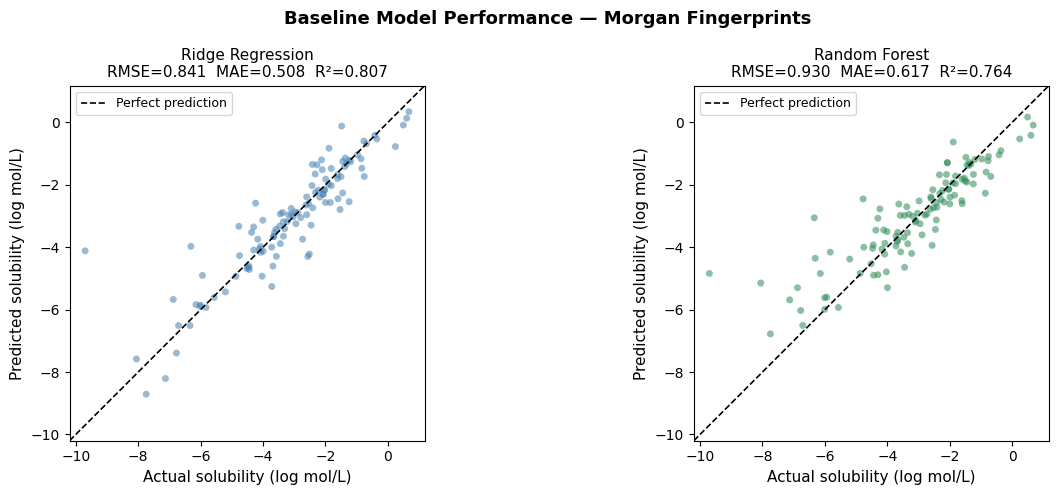

What to look for:
  - How tight is the scatter around the diagonal?
  - Are there systematic errors at the extremes (very high or very low solubility)?
  - Does RF outperform Ridge? If yes, the relationship is nonlinear.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models     = [('Ridge Regression', ridge), ('Random Forest', rf)]
results    = [ridge_results, rf_results]
colors     = ['steelblue', 'seagreen']

for ax, (name, model), res, color in zip(axes, models, results, colors):
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.55, s=25, color=color, edgecolors='none')

    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()) - 0.5,
            max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')

    ax.set_xlabel('Actual solubility (log mol/L)', fontsize=11)
    ax.set_ylabel('Predicted solubility (log mol/L)', fontsize=11)
    ax.set_title(f'{name}\nRMSE={res["rmse"]:.3f}  MAE={res["mae"]:.3f}  R²={res["r2"]:.3f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')

plt.suptitle('Baseline Model Performance — Morgan Fingerprints', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section5_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

print("What to look for:")
print("  - How tight is the scatter around the diagonal?")
print("  - Are there systematic errors at the extremes (very high or very low solubility)?")
print("  - Does RF outperform Ridge? If yes, the relationship is nonlinear.")

---
## Section 5 Complete — What You Should Understand

1. **Morgan fingerprints are a fixed, hand-crafted representation.** They encode which substructures are present but not how they're arranged globally. Length is always 2048 regardless of molecule size.

2. **Random Forest is a strong baseline for fingerprint inputs.** It handles sparse high-dimensional data well and requires no tuning to be competitive.

3. **These results are your benchmark.** Write down the RMSE and R² numbers. Everything from Section 8 onward will be compared against them.

4. **If RF R² is around 0.80–0.90, that's typical for ESOL with random split.** It's a relatively easy dataset. The GNN should match or slightly exceed this.

---

## What output you should see

- Ridge Regression: RMSE around 1.0–1.2, R² around 0.70–0.80
- Random Forest: RMSE around 0.8–1.0, R² around 0.80–0.88
- RF should clearly outperform Ridge — solubility is a nonlinear function of structure
- The scatter plot should show a clear diagonal trend with more spread at the extremes

---

## What Section 6 will do

We build our first GNN — a Graph Convolutional Network (GCN).

You'll see the message passing idea made concrete in code: each atom aggregates information from its bonded neighbors, updates its own representation, and after a few rounds every atom's vector reflects its broader chemical context.

Then we pool all atom vectors into a single graph-level vector and predict solubility from it.

**When you're ready, move on to Section 6.**

---
# Section 6: Simple GCN Model

**What we're doing:** Building our first Graph Neural Network — a Graph Convolutional Network (GCN).

**Why GCN first?** It's the simplest GNN architecture that still does real message passing. Understanding it gives you the foundation for every more advanced model (GIN, GAT, MPNN, etc.).

## The core idea: message passing

Before writing any code, here is what a GNN actually does, step by step:

```
Round 1 of message passing:
  Each atom looks at all its bonded neighbors.
  It collects their feature vectors.
  It aggregates them (e.g. takes the mean).
  It updates its own vector using that aggregated information.

After round 1: each atom's vector reflects its immediate neighborhood.
After round 2: each atom's vector reflects its 2-hop neighborhood.
After k rounds: each atom knows about everything within k bonds of it.
```

This is called **message passing** or **neighborhood aggregation**.

The GCN formulation (Kipf & Welling, 2017) does this with a normalized sum:

```
h_v^(k+1) = ReLU( W * mean( h_u^(k) for u in neighbors(v) + {v} ) )
```

Where `h_v` is the feature vector for atom `v` and `W` is a learned weight matrix.

## The full pipeline

```
x  [num_atoms, 25]          ← atom feature matrix (input)
    ↓
GCNConv layer 1             ← message passing, learns local patterns
    ↓  [num_atoms, 64]
ReLU
    ↓
GCNConv layer 2             ← second round of message passing
    ↓  [num_atoms, 64]
global_mean_pool            ← average all atom vectors → one graph vector
    ↓  [1, 64]
Linear layer                ← map graph vector to a single number
    ↓  [1]
Predicted solubility
```

**Pooling** is the step that turns a variable-size set of atom vectors into a fixed-size graph vector. We use mean pooling — the simplest option. The resulting vector is sometimes called the **molecular embedding**.

**What can go wrong:** GCNConv assumes an undirected graph with self-loops added. If `edge_index` doesn't have both directions for each bond (which ours does — we built it that way in Section 2), message passing won't work correctly.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        """
        A simple two-layer GCN for graph-level regression.

        Args:
            input_dim:  number of atom features (25 in our case)
            hidden_dim: size of the internal node embedding (tunable)
            output_dim: 1 for regression (predicting a single number)
        """
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        """
        Forward pass through the GCN.

        Args:
            x:          node features,  shape [total_atoms_in_batch, input_dim]
            edge_index: graph edges,    shape [2, total_edges_in_batch]
            batch:      batch vector,   shape [total_atoms_in_batch]
                        maps each atom to its molecule index in the batch

        Returns:
            out: predicted property,   shape [num_molecules_in_batch, 1]
        """
        # --- Message passing round 1 ---
        h = self.conv1(x, edge_index)   # [total_atoms, hidden_dim]
        h = F.relu(h)

        # --- Message passing round 2 ---
        h = self.conv2(h, edge_index)   # [total_atoms, hidden_dim]
        h = F.relu(h)

        # --- Global mean pooling ---
        # Aggregates all atom vectors for each molecule into one graph vector
        h = global_mean_pool(h, batch)  # [num_molecules, hidden_dim]

        # --- Final prediction ---
        out = self.lin(h)               # [num_molecules, 1]
        return out


# Instantiate and inspect the model
gcn_model = GCN(input_dim=FEATURE_DIM, hidden_dim=64)
print(gcn_model)
print()

total_params = sum(p.numel() for p in gcn_model.parameters())
print(f"Total trainable parameters: {total_params:,}")
print()
print("Compare to the dataset:")
print(f"  Training molecules: {len(train_data)}")
print(f"  Model parameters:   {total_params:,}")
print("  This is a small model — appropriate for a dataset of ~1000 molecules.")

## Step 6.1 — Inspect intermediate tensor shapes

Before training, let's run a single molecule through the model and print the shape at every step.
This is one of the most useful debugging habits in deep learning.

In [ ]:
from torch_geometric.data import Batch

# Take one molecule from the training set
sample = train_data[0]
print(f"Single molecule:")
print(f"  x.shape          = {list(sample.x.shape)}   ← [{sample.x.shape[0]} atoms × {sample.x.shape[1]} features]")
print(f"  edge_index.shape = {list(sample.edge_index.shape)}")
print(f"  y                = {sample.y.item():.3f} log mol/L")
print()

# Wrap it in a batch of size 1 (required by PyG's forward pass)
batch = Batch.from_data_list([sample])

# Run a forward pass with no gradient tracking (just for inspection)
gcn_model.eval()
with torch.no_grad():
    # After conv1
    h1 = F.relu(gcn_model.conv1(batch.x, batch.edge_index))
    print(f"After GCNConv layer 1 + ReLU: {list(h1.shape)}  ← [atoms, hidden_dim]")

    # After conv2
    h2 = F.relu(gcn_model.conv2(h1, batch.edge_index))
    print(f"After GCNConv layer 2 + ReLU: {list(h2.shape)}  ← [atoms, hidden_dim]")

    # After pooling
    h3 = global_mean_pool(h2, batch.batch)
    print(f"After global mean pool:       {list(h3.shape)}  ← [1 molecule, hidden_dim]")

    # After linear
    out = gcn_model.lin(h3)
    print(f"After linear layer:           {list(out.shape)}  ← [1 molecule, 1 prediction]")
    print(f"  Predicted solubility: {out.item():.4f}  (untrained, so this is meaningless)")
    print(f"  Actual solubility:    {sample.y.item():.4f}")

---
# Section 7: Training Loop

**What we're doing:** Teaching the GCN to predict solubility by showing it many molecules and adjusting its weights to reduce prediction error.

**The training loop in plain English:**
```
For each epoch (pass through the training set):
    For each batch of molecules:
        1. Feed molecules through the GCN → get predictions
        2. Compare predictions to actual solubility values → compute loss
        3. Backpropagate: figure out how to adjust weights to reduce loss
        4. Update weights (optimizer step)
    Compute validation loss (no weight updates)
    Print progress
```

**Loss function:** Mean Squared Error (MSE). We penalize the squared difference between predicted and actual solubility. The square punishes large errors more than small ones.

**Optimizer:** Adam. The standard choice for deep learning. It adapts the learning rate per parameter, which generally makes training faster and more stable than plain SGD.

**Batching:** PyG's `DataLoader` handles batching graphs. It stacks multiple graphs into one large disconnected graph, using a `batch` vector to track which atoms belong to which molecule. This is what allows `global_mean_pool` to correctly average per-molecule.

In [ ]:
from torch_geometric.loader import DataLoader

# --- Hyperparameters ---
BATCH_SIZE  = 32    # molecules per gradient update
HIDDEN_DIM  = 64    # size of node embeddings inside the GCN
LEARN_RATE  = 1e-3  # how fast the optimizer moves
NUM_EPOCHS  = 100   # how many full passes through the training data

# --- Data loaders ---
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

# --- Model, loss, optimizer ---
gcn_model  = GCN(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM)
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(gcn_model.parameters(), lr=LEARN_RATE)

print(f"Training set:   {len(train_data)} molecules → {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Validation set: {len(val_data)} molecules")
print(f"Test set:       {len(test_data)} molecules")
print(f"Model:          GCN with hidden_dim={HIDDEN_DIM}")
print(f"Loss:           MSELoss")
print(f"Optimizer:      Adam (lr={LEARN_RATE})")
print(f"Epochs:         {NUM_EPOCHS}")

In [ ]:
import math

def train_one_epoch(model, loader, optimizer, criterion):
    """Run one pass through the training data, updating weights."""
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()                              # clear gradients from last step
        pred = model(batch.x, batch.edge_index, batch.batch)  # forward pass
        loss = criterion(pred.squeeze(), batch.y)          # compute MSE loss
        loss.backward()                                    # backpropagate
        optimizer.step()                                   # update weights
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Compute loss on a dataset without updating weights."""
    model.eval()
    total_loss = 0
    for batch in loader:
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(pred.squeeze(), batch.y)
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


# --- Training loop ---
train_losses = []
val_losses   = []
best_val     = float('inf')
best_weights = None

print(f"{'Epoch':>6}  {'Train RMSE':>10}  {'Val RMSE':>9}")
print("-" * 32)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(gcn_model, train_loader, optimizer, criterion)
    val_loss   = evaluate(gcn_model, val_loader, criterion)

    train_losses.append(math.sqrt(train_loss))
    val_losses.append(math.sqrt(val_loss))

    # Save the best model weights based on validation loss
    if val_loss < best_val:
        best_val     = val_loss
        best_weights = {k: v.clone() for k, v in gcn_model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {math.sqrt(train_loss):>10.4f}  {math.sqrt(val_loss):>9.4f}")

# Restore best weights before evaluation
gcn_model.load_state_dict(best_weights)
print()
print(f"Training complete. Best validation RMSE: {math.sqrt(best_val):.4f}")

---
# Section 8: Evaluation

**What we're doing:** Measuring how well the trained GCN generalizes to molecules it has never seen.

We use three metrics:
- **RMSE** (Root Mean Squared Error) — in the same units as the target (log mol/L). Lower is better.
- **MAE** (Mean Absolute Error) — average absolute prediction error per molecule. Easier to interpret.
- **R²** — fraction of variance explained. 1.0 = perfect. 0.0 = predicting the mean every time. Can be negative.

We also compare against the baseline from Section 5.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

@torch.no_grad()
def get_predictions(model, loader):
    """Return (y_true, y_pred) numpy arrays for a dataset."""
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        pred = model(batch.x, batch.edge_index, batch.batch)
        y_true.extend(batch.y.tolist())
        y_pred.extend(pred.squeeze().tolist())
    return np.array(y_true), np.array(y_pred)


gcn_true, gcn_pred = get_predictions(gcn_model, test_loader)

gcn_rmse = np.sqrt(mean_squared_error(gcn_true, gcn_pred))
gcn_mae  = mean_absolute_error(gcn_true, gcn_pred)
gcn_r2   = r2_score(gcn_true, gcn_pred)

print("=" * 55)
print("TEST SET RESULTS — GCN vs Baselines")
print("=" * 55)
print(f"  {'Model':<26} {'RMSE':>6}  {'MAE':>6}  {'R²':>6}")
print(f"  {'-'*26} {'-'*6}  {'-'*6}  {'-'*6}")
print(f"  {'Ridge Regression':<26} {ridge_results['rmse']:>6.3f}  {ridge_results['mae']:>6.3f}  {ridge_results['r2']:>6.3f}")
print(f"  {'Random Forest':<26} {rf_results['rmse']:>6.3f}  {rf_results['mae']:>6.3f}  {rf_results['r2']:>6.3f}")
print(f"  {'GCN (ours)':<26} {gcn_rmse:>6.3f}  {gcn_mae:>6.3f}  {gcn_r2:>6.3f}")
print()
print("Interpretation:")
print(f"  GCN vs RF RMSE improvement: {rf_results['rmse'] - gcn_rmse:+.3f} log mol/L")
if gcn_rmse < rf_results['rmse']:
    print("  ✓ GCN outperforms the fingerprint baseline.")
else:
    print("  The fingerprint baseline is still competitive — this is normal on small datasets.")
    print("  GNN advantages typically become clearer with larger datasets (>10k molecules).")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: predicted vs actual ---
ax1 = axes[0]
ax1.scatter(gcn_true, gcn_pred, alpha=0.55, s=25, color='steelblue', edgecolors='none', label='GCN')
lims = [min(gcn_true.min(), gcn_pred.min()) - 0.5,
        max(gcn_true.max(), gcn_pred.max()) + 0.5]
ax1.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
ax1.set_xlabel('Actual solubility (log mol/L)', fontsize=11)
ax1.set_ylabel('Predicted solubility (log mol/L)', fontsize=11)
ax1.set_title(f'GCN: Predicted vs Actual\nRMSE={gcn_rmse:.3f}  MAE={gcn_mae:.3f}  R²={gcn_r2:.3f}', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_xlim(lims); ax1.set_ylim(lims); ax1.set_aspect('equal')

# --- Right: train/val loss curves ---
ax2 = axes[1]
ax2.plot(train_losses, label='Train RMSE', color='steelblue')
ax2.plot(val_losses,   label='Val RMSE',   color='orange')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('RMSE (log mol/L)', fontsize=11)
ax2.set_title('Training and Validation Loss Curves', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('section8_gcn_eval.png', dpi=120, bbox_inches='tight')
plt.show()

print("What to look for in the loss curves:")
print("  - Both curves declining = model is learning")
print("  - Val curve diverging upward = overfitting")
print("  - Val curve flat and high = underfitting / learning rate too low")

In [ ]:
# Show 5 example predictions from the test set
print("=" * 70)
print("EXAMPLE PREDICTIONS — 5 molecules from the test set")
print("=" * 70)

errors = np.abs(gcn_true - gcn_pred)

# Pick: 2 best predictions, 2 worst, 1 median
sorted_idx  = np.argsort(errors)
sample_idx  = [sorted_idx[0], sorted_idx[1],
               sorted_idx[len(sorted_idx)//2],
               sorted_idx[-2], sorted_idx[-1]]

# Retrieve the smiles for test set molecules
test_smiles = []
for d in test_data:
    y_val = d.y.item()
    match = df[np.isclose(df['solubility'], y_val, atol=1e-5)]
    test_smiles.append(match.iloc[0]['smiles'] if len(match) > 0 else 'N/A')

labels = ['Best 1', 'Best 2', 'Median', 'Worst 2', 'Worst 1']
print(f"  {'Label':<10} {'Actual':>7}  {'Predicted':>9}  {'Error':>6}  SMILES")
print(f"  {'-'*10} {'-'*7}  {'-'*9}  {'-'*6}  {'-'*30}")
for label, i in zip(labels, sample_idx):
    smiles = test_smiles[i] if i < len(test_smiles) else 'N/A'
    print(f"  {label:<10} {gcn_true[i]:>7.3f}  {gcn_pred[i]:>9.3f}  {errors[i]:>6.3f}  {smiles[:45]}")

print()
print("The 'worst' predictions often correspond to:")
print("  - Unusual scaffolds not well represented in training data")
print("  - Molecules at the extremes of the solubility range")
print("  - Molecules with unusual functional groups")

---
# Section 9: GIN Model

**What we're doing:** Replacing the GCN with a Graph Isomorphism Network (GIN) and comparing the two.

## Why GIN?

GCN uses a normalized mean to aggregate neighbor information. This is simple but has a theoretical limitation: **it cannot distinguish certain non-isomorphic graphs**.

In plain English: two molecules with different structures can produce the same representation after GCN message passing, making them indistinguishable to the model.

GIN (Xu et al., 2019) was designed to fix this. It uses a learnable aggregation:

```
GCN:  h_v = ReLU( W * mean(neighbors + self) )          ← fixed mean
GIN:  h_v = MLP( (1 + ε) * h_v + sum(neighbors) )       ← learnable MLP
```

GIN is theoretically as powerful as the Weisfeiler-Lehman graph isomorphism test — the most expressive 1-hop neighborhood aggregation possible. In practice it's often a strong baseline for molecular tasks.

The architecture is otherwise identical: two message-passing layers, global mean pooling, linear output.

In [ ]:
from torch_geometric.nn import GINConv

class GIN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=1):
        super(GIN, self).__init__()

        # GINConv wraps a neural network (the MLP) as the aggregator
        mlp1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        h = global_mean_pool(h, batch)
        return self.lin(h)


# Train GIN with the same hyperparameters as GCN
gin_model  = GIN(input_dim=FEATURE_DIM, hidden_dim=HIDDEN_DIM)
gin_optim  = torch.optim.Adam(gin_model.parameters(), lr=LEARN_RATE)

gin_train_losses, gin_val_losses = [], []
best_gin_val, best_gin_weights   = float('inf'), None

print(f"{'Epoch':>6}  {'Train RMSE':>10}  {'Val RMSE':>9}")
print("-" * 32)

for epoch in range(1, NUM_EPOCHS + 1):
    tl = train_one_epoch(gin_model, train_loader, gin_optim, criterion)
    vl = evaluate(gin_model, val_loader, criterion)
    gin_train_losses.append(math.sqrt(tl))
    gin_val_losses.append(math.sqrt(vl))
    if vl < best_gin_val:
        best_gin_val     = vl
        best_gin_weights = {k: v.clone() for k, v in gin_model.state_dict().items()}
    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>6}  {math.sqrt(tl):>10.4f}  {math.sqrt(vl):>9.4f}")

gin_model.load_state_dict(best_gin_weights)
print(f"\nBest GIN validation RMSE: {math.sqrt(best_gin_val):.4f}")

In [ ]:
gin_true, gin_pred = get_predictions(gin_model, test_loader)
gin_rmse = np.sqrt(mean_squared_error(gin_true, gin_pred))
gin_mae  = mean_absolute_error(gin_true, gin_pred)
gin_r2   = r2_score(gin_true, gin_pred)

print("=" * 60)
print("FINAL MODEL COMPARISON — Test Set")
print("=" * 60)
print(f"  {'Model':<30} {'RMSE':>6}  {'MAE':>6}  {'R²':>6}")
print(f"  {'-'*30} {'-'*6}  {'-'*6}  {'-'*6}")
print(f"  {'Ridge Regression (fingerprints)':<30} {ridge_results['rmse']:>6.3f}  {ridge_results['mae']:>6.3f}  {ridge_results['r2']:>6.3f}")
print(f"  {'Random Forest (fingerprints)':<30} {rf_results['rmse']:>6.3f}  {rf_results['mae']:>6.3f}  {rf_results['r2']:>6.3f}")
print(f"  {'GCN (graph neural network)':<30} {gcn_rmse:>6.3f}  {gcn_mae:>6.3f}  {gcn_r2:>6.3f}")
print(f"  {'GIN (graph neural network)':<30} {gin_rmse:>6.3f}  {gin_mae:>6.3f}  {gin_r2:>6.3f}")

# Visual loss curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_losses,     label='GCN train', color='steelblue',  linestyle='-')
ax1.plot(val_losses,       label='GCN val',   color='steelblue',  linestyle='--')
ax1.plot(gin_train_losses, label='GIN train', color='seagreen',   linestyle='-')
ax1.plot(gin_val_losses,   label='GIN val',   color='seagreen',   linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('RMSE')
ax1.set_title('GCN vs GIN — Loss Curves'); ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.scatter(gcn_true, gcn_pred, alpha=0.4, s=20, label=f'GCN (R²={gcn_r2:.3f})', color='steelblue')
ax2.scatter(gin_true, gin_pred, alpha=0.4, s=20, label=f'GIN (R²={gin_r2:.3f})', color='seagreen')
lims = [-12, 3]
ax2.plot(lims, lims, 'k--', linewidth=1)
ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
ax2.set_title('Predicted vs Actual — GCN and GIN'); ax2.legend(); ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('section9_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Section 10: Drug Development Interpretation

No code in this section. This is where we step back and connect what we built to the real world.

---

## What part of the drug discovery pipeline did we simulate?

We built a model for **ADMET property prediction** — specifically, aqueous solubility.

In a real discovery pipeline, this sits here:

```
1. Target identification       ← find a protein involved in the disease
2. Hit discovery               ← screen millions of molecules for any binding activity
3. Hit-to-lead                 ← refine the best hits into drug-like leads
4. Lead optimization           ← improve potency, selectivity, ADMET properties  ← WE ARE HERE
5. Preclinical development     ← animal studies, safety testing
6. Clinical trials (Phase I–III)
7. Regulatory approval
```

ADMET prediction is used to **filter and prioritize** molecules during lead optimization. A computational chemist might generate 10,000 candidate molecules and use a model like ours to instantly flag the ones with poor predicted solubility — saving weeks of experimental work.

---

## What is useful about this?

- **Speed**: Predicting solubility computationally takes milliseconds. Measuring it experimentally takes days and costs tens of dollars per compound.
- **Scale**: You can screen millions of virtual molecules before synthesizing anything.
- **Early triage**: Catch likely failures before spending money on synthesis and testing.
- **Multi-objective optimization**: Run predictions for solubility, toxicity, and binding affinity simultaneously to find molecules that are good on all fronts.

---

## What are the limitations?

**1. The model only knows what it was trained on.**
Our model was trained on ~1,000 known organic molecules. If a candidate molecule has a scaffold that's structurally unlike anything in the training set, predictions will be unreliable. This is the out-of-distribution (OOD) problem — and it's a fundamental, unsolved challenge in the field.

**2. Solubility alone isn't enough.**
A drug needs good scores on many properties simultaneously: solubility, membrane permeability, metabolic stability, toxicity, binding affinity. Models like ours address only one of these.

**3. The dataset is small and noisy.**
ESOL has 1,128 molecules. Real pharmaceutical ADMET datasets have tens of thousands — and even those are small by deep learning standards. Experimental measurements also have inherent noise (~0.5 log units for solubility).

**4. Correlation is not causation.**
A model trained to predict measured solubility from structure is learning correlations. It doesn't understand why polar molecules are more soluble — it's pattern matching. This means it can make confident wrong predictions for structurally unusual molecules.

**5. Scaffold split performance would be lower.**
We used a random split. If we had used a scaffold split (train and test on structurally distinct molecules), our reported RMSE and R² would likely be meaningfully worse. That would be the more honest number for real-world use.

---

## Why is this not enough to claim a drug works?

We predicted **aqueous solubility** — one physical property, measured in a test tube.

A working drug requires all of the following, none of which we tested:
- Binds to the right protein target with sufficient affinity
- Does not bind to off-target proteins (selectivity)
- Reaches the right tissue/organ (distribution)
- Is not metabolized too quickly (metabolic stability)
- Is not toxic to healthy cells
- Works in animal models
- Works in humans across a diverse population
- Has an acceptable safety profile at therapeutic doses

Each of those is a separate model, a separate experimental assay, and a separate hurdle. Our model addresses one small piece of one early stage.

---

## What would come next in a more realistic workflow?

| Next step | What it requires |
|---|---|
| Predict all ADMET properties | Multi-task GNN trained on Tox21, ClinTox, BBBP, etc. |
| Predict target binding affinity | Structure-based models (docking, DiffDock) or ligand-based GNNs |
| Virtual screening | Run predictions on libraries of millions of purchasable molecules |
| Multi-objective optimization | Simultaneously optimize solubility, toxicity, binding affinity |
| Generative design | Use a diffusion model to propose new molecules with desired properties |
| Synthesis + wet lab testing | Experimental validation — the model's predictions are hypotheses, not facts |

The GNN you built is the **discriminative foundation** of this pipeline. Everything else builds on top of the ability to predict molecular properties from graph structure.

---
# Section 11: Optional Extensions

The core pipeline is complete. These are self-contained next steps — pick whichever interests you most.

---

## Option A — BBBP: Blood-Brain Barrier Penetration (Classification)

**The task:** Predict whether a molecule can cross the blood-brain barrier (binary: yes/no).

**Why it matters:** CNS drugs (for depression, Alzheimer's, Parkinson's) must reach the brain. Most molecules can't cross the BBB. Predicting this computationally saves huge amounts of experimental work.

**What changes from our current code:**
- Target variable: binary (0/1) instead of continuous
- Loss function: `BCEWithLogitsLoss` instead of `MSELoss`
- Output activation: sigmoid instead of linear
- Metrics: AUC-ROC, accuracy, F1 instead of RMSE

```python
# Load BBBP
BBBP_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv'
df_bbbp = pd.read_csv(BBBP_URL)
# Column 'p_np': 1 = penetrates BBB, 0 = does not
```

---

## Option B — BACE: Beta-Secretase Inhibitor Classification

**The task:** Predict whether a molecule inhibits BACE-1, an enzyme implicated in Alzheimer's disease.

**Why it matters:** This is closer to a real drug discovery task — predicting activity against a specific disease target rather than a physical property.

**What changes:** Same as BBBP (binary classification). The interesting part is interpreting which structural features the model associates with BACE inhibition.

```python
BACE_URL = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/bace.csv'
df_bace = pd.read_csv(BACE_URL)
# Column 'Class': 1 = inhibitor, 0 = non-inhibitor
```

---

## Option C — ChEMBL EGFR: Predict Activity Against a Cancer Target

**The task:** Given molecules tested against EGFR (a kinase mutated in many lung cancers), predict active vs. inactive.

**Why it matters:** EGFR inhibitors (gefitinib, erlotinib) are approved lung cancer drugs. This dataset puts you directly in the context of real oncology drug discovery.

**What changes:** Data loading from ChEMBL (requires the `chembl_webresource_client` package). Otherwise the pipeline is identical to BACE.

```python
!pip install chembl_webresource_client
from chembl_webresource_client.new_client import new_client
# Query EGFR (CHEMBL203) activity data
```

---

## Option D — Chemprop: Compare Against a Production GNN

**The task:** Run the same ESOL dataset through Chemprop (MIT's production D-MPNN) and compare its RMSE to ours.

**Why it matters:** Chemprop is what researchers and some pharma companies actually use. Seeing how our hand-built GNN compares to a production tool puts our work in honest context.

```python
!pip install chemprop
```

Then train from the command line:
```bash
chemprop train \
  --data_path delaney-processed.csv \
  --smiles_column smiles \
  --target_columns solubility \
  --save_dir chemprop_model
```

Chemprop typically achieves RMSE around 0.55–0.70 on ESOL — noticeably better than our GCN/GIN because it uses directed message passing, better features, and is heavily optimized. The gap shows you what production engineering buys beyond the core architecture.

---

## What you've built

```
✓ SMILES → RDKit molecule object
✓ Molecule → molecular graph (atoms=nodes, bonds=edges)
✓ Atom properties → node feature vectors (25-dimensional)
✓ Morgan fingerprint baseline (Ridge + Random Forest)
✓ PyTorch Geometric Data objects
✓ Train/val/test split
✓ GCN with message passing + global pooling
✓ Training loop with loss curves
✓ GIN model
✓ Full model comparison table
✓ Drug development context and honest limitations
```

This is the complete foundational GNN drug discovery pipeline. Everything in the optional extensions — and everything your friend described about diffusion models — builds on exactly what you've learned here.

---
# Section 12: What's Next — The Full Learning Roadmap

You've completed the foundational GNN drug discovery pipeline. Here is an honest map of what comes next — each step, what it is, what you need to understand before attempting it, and what it unlocks.

This is not a checklist. It's a map. You don't have to follow it linearly, but each level genuinely depends on the one before it.

---

## Level 1 — Where you are now ✅
### GNN Property Prediction

**What you built:** A model that takes a molecular graph and predicts a number (solubility).

**What you learned:**
- Molecules are graphs. Atoms are nodes. Bonds are edges.
- Node features encode atom properties. Edge index encodes connectivity.
- Message passing: each atom aggregates information from its neighbors.
- Global pooling: collapse a variable-size graph into a fixed-size vector.
- GCN vs GIN: mean aggregation vs learnable MLP aggregation.
- The pipeline matters as much as the model: data loading, featurization, splitting, evaluation.

**What this enables in the real world:** ADMET prediction, virtual screening triage, multi-task property prediction across solubility/toxicity/permeability simultaneously.

**Key papers to read if you want to go deeper:**
- Kipf & Welling 2017 — *Semi-Supervised Classification with Graph Convolutional Networks* (the GCN paper)
- Xu et al. 2019 — *How Powerful are Graph Neural Networks?* (the GIN paper)
- Yang et al. 2019 — *Analyzing Learned Molecular Representations for Property Prediction* (the Chemprop/D-MPNN paper)

---

## Level 2 — Next step
### Understand Molecular Graphs More Deeply

**What this means:** Before jumping to generative models, there are important concepts about molecular graph representations that most tutorials skip.

**What to learn:**

**Directed message passing (D-MPNN):** Instead of aggregating over atoms, aggregate over *bonds*. Each bond carries a message in one direction. This is what Chemprop uses and why it outperforms standard GCN — bond-level messages prevent a node from sending its own information back to itself.

**Graph attention (GAT):** Instead of treating all neighbors equally (GCN) or using a fixed MLP (GIN), learn *attention weights* that say how much each neighbor should contribute. Atoms in an aromatic ring should probably weight their ring neighbors differently than their substituents.

**3D molecular graphs:** Everything we built ignores 3D coordinates. Real molecules exist in 3D space, and the spatial arrangement of atoms matters enormously for binding. This is where SchNet, DimeNet, and PaiNN come in — they encode interatomic distances and angles as edge features.

**What to build:** Take your GCN and replace `GCNConv` with `GATConv` (already in PyG). Observe whether attention weights correlate with known chemistry — do aromatic atoms attend more to each other?

**Key papers:**
- Veličković et al. 2018 — *Graph Attention Networks*
- Schütt et al. 2017 — *SchNet: A continuous-filter convolutional neural network for modeling quantum interactions*
- Gasteiger et al. 2020 — *Directional Message Passing for Molecular Graphs* (DimeNet)

---

## Level 3
### Graph-Based Generative Models (VAEs and Flows)

**What this means:** Shifting from *predicting* a property of a given molecule to *generating* new molecules with desired properties.

**The conceptual shift:** In property prediction, the input is a graph and the output is a number. In generation, the input is a number (or a target property) and the output is a graph. This is much harder — you're now in the space of discrete, structured objects.

**Variational Autoencoders (VAEs) for molecules:**
A VAE encodes a molecule into a point in a continuous latent space, then decodes a new molecule from nearby points. The famous result: if the latent space is smooth, you can do *latent space arithmetic* — find a molecule with good solubility, find a molecule with good binding affinity, and interpolate between them to find candidates that balance both.

```
Molecule → GNN Encoder → latent vector z → GNN Decoder → new molecule
                                ↑
                    optimize z toward desired properties
```

**Normalizing flows for molecules:** An alternative to VAEs that learns an exact, invertible mapping between molecule space and a Gaussian. Cleaner mathematically but harder to train.

**Why this level matters:** VAEs and flows introduce the latent space concept that diffusion models later generalize. You can't really understand what a diffusion model is denoising *toward* without first understanding what a well-structured latent space looks like.

**What to build:** JT-VAE (Junction Tree VAE) is the classic starting point. It's complex but the original code is available. Alternatively, start with a simpler SMILES-based VAE (character-level) before attempting a graph VAE.

**Key papers:**
- Jin et al. 2018 — *Junction Tree Variational Autoencoder for Molecular Graph Generation*
- Kruse et al. 2021 — *GraphNVP: An Invertible Flow Model for Generating Molecular Graphs*

---

## Level 4
### Equivariant GNNs — SE(3)-Invariant Networks

**What this means:** Building GNNs that respect the physical symmetries of molecules in 3D space.

**The problem:** If you rotate or translate a molecule in 3D, it's the same molecule. A standard GNN trained on 3D coordinates doesn't know this — it would predict different properties for the same molecule in different orientations. That's wrong.

**Equivariance:** A function is equivariant to a transformation if rotating the input rotates the output in the same way. For molecular property prediction we actually want *invariance* — the predicted solubility shouldn't change if we rotate the molecule. For generative models we want *equivariance* — if we rotate the input, the generated molecule should rotate accordingly.

**Why this is the building block of RFDiffusion:** RFDiffusion uses SE(3)-equivariant message passing (from RoseTTAFold's IPA module) as its denoising network. Without understanding equivariance, RFDiffusion is a black box. With it, you can read the architecture and understand every design choice.

**The key insight:** Instead of passing scalar features between atoms, equivariant GNNs pass *vectors and tensors* that transform correctly under rotation. This requires learning with spherical harmonics and irreducible representations — mathematically heavier than anything in Levels 1–3.

**What to build:** Start with EGNN (Equivariant Graph Neural Networks by Satorras et al.) — it's the most readable equivariant GNN and has clean PyTorch code. Train it on a 3D molecular property dataset (QM9).

**Key papers:**
- Satorras et al. 2021 — *E(n) Equivariant Graph Neural Networks* (EGNN — the readable starting point)
- Thomas et al. 2018 — *Tensor Field Networks* (foundational theory)
- Fuchs et al. 2020 — *SE(3)-Transformers* (used in protein structure work)

---

## Level 5
### Diffusion Models on Graphs

**What this means:** Using the denoising diffusion framework — which you may know from image generation (DALL-E, Stable Diffusion) — but applied to molecular graphs in 3D.

**How diffusion works, briefly:**
```
Forward process:  real molecule → add noise gradually → pure noise
Reverse process:  pure noise → denoise step by step → new molecule

The model learns the reverse process.
At generation time: start from noise, run the reverse process.
```

**Why graphs make this hard:** Images are regular grids — easy to add Gaussian noise. Molecular graphs are discrete (atom types), continuous (3D coordinates), and variable-size. Different components need different noise processes.

**DiffSBDD:** Structure-based drug design. Given a protein binding pocket, generate a small molecule that fits into it. Uses an equivariant GNN (EGNN) as the denoising network. This is why Level 4 is a prerequisite.

**DiffDock:** Reframes *docking* (placing a known molecule into a protein) as a diffusion process over the molecule's position, orientation, and torsion angles. Achieves state-of-the-art docking accuracy.

**What to build:** The DiffSBDD codebase is public and reasonably readable if you've done Levels 1–4. Start by running inference (generate molecules for a known pocket) before trying to understand training.

**Key papers:**
- Ho et al. 2020 — *Denoising Diffusion Probabilistic Models* (the foundational DDPM paper — read this first)
- Schneuing et al. 2022 — *Structure-based Drug Design with Equivariant Diffusion Models* (DiffSBDD)
- Corso et al. 2022 — *DiffDock: Diffusion Steps, Twists, and Turns for Molecular Docking*

---

## Level 6 — The frontier
### Full Protein Design Pipelines

**What this means:** End-to-end computational design of proteins with desired functions, with experimental validation.

**The RFDiffusion + ProteinMPNN pipeline:**
```
1. RFDiffusion     → generate a protein backbone (3D coordinates of Cα atoms)
2. ProteinMPNN     → given the backbone, design the amino acid sequence that folds into it
3. AlphaFold2/3    → verify: does the designed sequence actually fold into the target backbone?
4. Wet lab         → synthesize, express, and experimentally test the designed protein
```

**Why this pipeline works so well:** RFDiffusion was initialized from RoseTTAFold weights — it started with a model that already understood protein structure. The PDB + AlphaFold predictions gave it millions of training examples. ProteinMPNN was trained on real protein structures. Each piece is deeply pretrained on rich data.

**What AlphaFold 3 / Isomorphic Labs adds:** Extends the same ideas to the interface between proteins and small molecules. Predict the 3D structure of a protein bound to a drug candidate. This closes the loop between small molecule design and protein design.

**What you'd need to get here:**
- Comfortable reading PyTorch code with equivariant operations
- Understand attention mechanisms (Transformers) — RFDiffusion uses IPA, which is attention over protein frames
- Familiarity with protein structure basics (Cα backbone, residues, PDB format)
- Access to a GPU with >16GB VRAM for running inference; much more for training

**Realistic timeline:** If you work through Levels 1–5 seriously, Level 6 is readable within 6–12 months of starting from Level 1. Running inference (not training) on RFDiffusion is possible much sooner.

**Key papers:**
- Watson et al. 2023 — *De novo design of protein structure and function with RFdiffusion* (Nature)
- Dauparas et al. 2022 — *Robust deep learning-based protein sequence design using ProteinMPNN*
- Abramson et al. 2024 — *Accurate structure prediction of biomolecular interactions with AlphaFold 3* (Nature)

---

## The honest summary

| Level | What you learn | Prerequisite for |
|---|---|---|
| 1 — GNN property prediction | Molecular graphs, message passing, pooling | Everything |
| 2 — Deeper graph understanding | D-MPNN, attention, 3D features | Level 3+ |
| 3 — Generative models (VAE/flow) | Latent spaces, reconstruction, generation | Level 5 |
| 4 — Equivariant GNNs | SE(3) symmetry, 3D-aware message passing | Level 5, 6 |
| 5 — Graph diffusion | Denoising, DiffSBDD, DiffDock | Level 6 |
| 6 — Protein design pipelines | RFDiffusion, ProteinMPNN, AlphaFold 3 | The frontier |

Your friend was right about where the frontier is. He was wrong to imply you should start there.

You can't meaningfully understand RFDiffusion without equivariant GNNs.
You can't understand equivariant GNNs without understanding what GNNs are doing in the first place.
You just learned that. That's Level 1 done.

---
# Section 13: Key Papers Reading List

No code. This section is a curated, annotated reading list organized to match the learning roadmap in Section 12.

---

## How to pick a good paper (the criteria I used)

Not all papers are equally worth reading at a given stage. Here's what I optimized for in this list:

| Criterion | What it means |
|---|---|
| **Conceptual leverage** | Reading it changes how you think, not just what you know |
| **Accessible entry point** | Can be understood without a PhD in the subfield — hard math is okay if the ideas are explained first |
| **Connects to what you built** | You should be able to map the paper's ideas directly onto the code you wrote |
| **Covers a key transition** | Each paper unlocks the next level in the roadmap |
| **Free to access** | All papers here have an arXiv or open-access version |
| **Historically important OR currently standard** | Either foundational (still cited everywhere) or defines current practice |

I excluded papers that are: too narrow, require heavy prerequisites you don't have yet, or are superseded by a more readable successor on the same idea.

---

## How to read these papers

You don't need to understand every equation on the first pass. For each paper:
1. **Read the abstract and introduction fully** — this tells you the problem and the claim
2. **Look at every figure** — most key ideas in ML papers are in the figures
3. **Read the experiments section** — what did they measure, on what datasets, how did they compare?
4. **Return to the methods** only after you understand what they were trying to do

The math will make more sense once you know what question it's answering.

---

## Level 1 papers — Read these first
### Directly extends what you built in this notebook

---

### 📄 Kipf & Welling (2017) — Semi-Supervised Classification with Graph Convolutional Networks
**ICLR 2017 | arXiv:1609.02907**

**Why I picked it:** This is the GCN you implemented. Reading the original paper after building it is the most efficient way to understand it — you already have the intuition, now you get the derivation. It's 9 pages and unusually readable for a theory paper.

**What it teaches:** How spectral graph convolution gets simplified into the neighborhood aggregation you wrote. The key insight is the renormalization trick — adding self-loops and normalizing by node degree — which is exactly what `GCNConv` does internally.

**What to look for:** Equation 2 is the core update rule. Map it directly onto your `conv1 = GCNConv(input_dim, hidden_dim)` line. The experiments section on citation networks will feel different from molecular tasks — notice that the setup is node classification (predicting properties of individual nodes), while we did graph classification (predicting a property of the whole graph).

**Reading difficulty:** ⭐⭐ — accessible. Light on prerequisites.

---

### 📄 Gilmer et al. (2017) — Neural Message Passing for Quantum Chemistry
**ICML 2017 | arXiv:1704.01212**

**Why I picked it:** This is the paper that gave us the formal language to describe every GNN architecture, including yours. Before Gilmer et al., every lab had their own notation for their own molecular GNN and nobody could compare them properly. After this paper, all GNNs are describable as: message function → aggregation → update → readout. That's exactly the structure of your training loop.

**What it teaches:** The MPNN framework unifies GCN, GIN, GAT, SchNet, DimeNet, and almost everything else you'll encounter. Once you read this, every subsequent architecture paper is just "here's how we parameterize the message function differently." It also introduces QM9 — a 130k molecule quantum chemistry benchmark you'll encounter repeatedly in future work.

**What to look for:** Table 1 — they rewrite 8 prior models as special cases of MPNN. Your GCN is in there. Section 3.1 defines message, aggregation, and update in a way you can map directly onto your `train_one_epoch` function.

**Reading difficulty:** ⭐⭐⭐ — moderate. Some quantum chemistry notation but the ML ideas are clean.

---

### 📄 Xu et al. (2019) — How Powerful are Graph Neural Networks?
**ICLR 2019 | arXiv:1810.00826**

**Why I picked it:** This is the theoretical justification for why GIN exists and why you implemented it in Section 9. If you've ever wondered "why does using sum instead of mean matter?" — this paper answers it rigorously.

**What it teaches:** GNNs are bounded in expressiveness by the Weisfeiler-Lehman graph isomorphism test. Mean and max aggregation are strictly less powerful than sum aggregation. GIN with a sum aggregator and learnable epsilon is maximally expressive within the 1-hop neighborhood framework. This is why GIN tends to outperform GCN on molecular tasks.

**What to look for:** Figure 1 — shows two graphs that GCN cannot distinguish but GIN can. Theorem 3 is the key result. The Appendix has the proof; skip it on the first read. The experimental results section shows GIN consistently beating GCN on graph classification benchmarks — the same pattern you likely saw in Section 9.

**Reading difficulty:** ⭐⭐⭐ — moderate. The theory section requires some graph theory background but the implications are explained intuitively.

---

### 📄 Yang et al. (2019) — Analyzing Learned Molecular Representations for Property Prediction
**JCIM 2019 | arXiv:1904.01561**

**Why I picked it:** This is the Chemprop paper — the production version of the exact pipeline you built. The gap between your GCN and Chemprop's D-MPNN is instructive: they use directed bond messages instead of undirected atom messages, which prevents a common information-flow problem. Reading this tells you exactly what to do after this notebook to get to production-quality molecular GNNs.

**What it teaches:** Directed message passing: instead of passing messages from atoms to atoms, you pass messages along directed bonds. This means atom A's information doesn't flow back to itself through bond A→B→A in the same round. It also introduces the atom and bond feature set used in production (more features than our 25-dimensional vector). And it provides an honest benchmark comparison that includes Morgan fingerprints — the same comparison you built in Section 5.

**What to look for:** Figure 1 — the directed bond message passing diagram. Table 1 — the benchmark results across 19 datasets. The gap between Chemprop and Morgan fingerprints on large datasets vs. small datasets. This maps directly onto the "GNN advantages become clearer with larger datasets" note in your Section 8.

**Reading difficulty:** ⭐⭐ — accessible. Primarily an empirical paper with clean experimental design.

---

### 📄 Stokes et al. (2020) — A Deep Learning Approach to Antibiotic Discovery
**Cell 2020 | DOI: 10.1016/j.cell.2020.01.021**

**Why I picked it:** This is the best answer to the question "does any of this actually matter?" It uses Chemprop (the paper above) trained on bacterial growth inhibition data, screens 6,111 compounds computationally, and identifies halicin — a structurally novel antibiotic that kills drug-resistant bacteria including C. difficile and M. tuberculosis. The compound is now in clinical development. This is the most cited translational paper connecting molecular GNNs to real drug discovery outcomes.

**What it teaches:** How the pipeline you built (train on measured property data → predict on new molecules → rank by predicted value → prioritize for experimental testing) works in a real discovery context. Also worth noting: the model has only ~2,300 training examples and still generalizes to structurally novel antibiotics — relevant to your Section 8 discussion of dataset size limitations.

**What to look for:** Figure 1 — the full workflow diagram. Figure 3 — the chemical structures of identified candidates and their similarity to training data. The supplement has the feature set and model architecture details. Note the model's AUROC, and notice that "good enough to prioritize" doesn't require perfect predictions.

**Reading difficulty:** ⭐⭐ — accessible. Biology-heavy but the ML sections are clear.

---

## Level 2 papers — Understanding molecular graphs more deeply

---

### 📄 Atz, Grisoni & Schneider (2021) — Geometric Deep Learning on Molecular Representations
**Nature Machine Intelligence | arXiv:2107.12375**

**Why I picked it:** This is the best "map" paper in the field. It organizes every molecular representation (graphs, grids, surfaces, strings, point clouds) and every geometric deep learning approach into a single coherent framework. Read it between Level 1 and Level 2 to get a bird's-eye view before diving into 3D architectures.

**What it teaches:** Why different molecular representations suit different tasks. Graphs suit topology-based property prediction (what you built). 3D point clouds suit conformational and binding problems. Surfaces suit protein-ligand interface modeling. The paper explains the geometric symmetries (translation, rotation, permutation invariance) that every good molecular model must respect — the conceptual foundation for understanding equivariant networks.

**What to look for:** Figure 1 — the taxonomy of molecular representations. Table 1 — which representation suits which task. The section on invariance and equivariance: this is the conceptual prerequisite for EGNN and RFDiffusion.

**Reading difficulty:** ⭐⭐ — deliberately accessible. Written as a review for practitioners.

---

### 📄 Veličković et al. (2018) — Graph Attention Networks
**ICLR 2018 | arXiv:1710.10903**

**Why I picked it:** Attention on graphs is the next architectural move after GCN and GIN. Understanding GAT prepares you for transformer-based molecular models (like Uni-Mol and Grover) and for the attention mechanism inside RFDiffusion's IPA (Invariant Point Attention) module.

**What it teaches:** Instead of treating all neighbors equally (GCN) or learning a fixed aggregation MLP (GIN), GAT learns a scalar attention weight for each neighbor pair. Conceptually: not all bonds carry equal information. An atom in a benzene ring should probably attend differently to its ring neighbors vs. its substituents. The attention mechanism lets the model learn this distinction from data.

**What to look for:** Equation 3 — the attention coefficient. Figure 1 — the attention head visualization. In PyG, you can swap `GCNConv` for `GATConv` in your model with two lines of code. Try it and check whether validation RMSE improves.

**Reading difficulty:** ⭐⭐ — clean and short (9 pages).

---

### 📄 Schütt et al. (2017) — SchNet: A Continuous-Filter Convolutional Neural Network for Modeling Quantum Interactions
**NeurIPS 2017 | arXiv:1706.08566**

**Why I picked it:** SchNet is the bridge between the graph-topology-only world you've been in (where edges just say "these atoms are bonded") and the 3D-geometry world (where edges carry distance information). It encodes interatomic distances using smooth continuous filters rather than discrete bond types. Every subsequent 3D molecular GNN — DimeNet, PaiNN, EGNN — builds on this idea.

**What it teaches:** Why ignoring 3D coordinates is a limitation. How to encode continuous distances as learnable filter functions. The QM9 benchmark for 3D molecular property prediction, which you'll see cited in every Level 4+ paper.

**What to look for:** Figure 1 — how distance-dependent filters replace discrete bond features. The QM9 results in Table 1. The discussion of rotational invariance — SchNet achieves it by using only pairwise distances (scalars), which is rotation-invariant by construction but can't distinguish mirror-image molecules. This limitation is what equivariant networks (Level 4) address.

**Reading difficulty:** ⭐⭐⭐ — moderate. Quantum chemistry notation is heavy but the architecture section is clear.

---

## Level 3 paper — Generative models

---

### 📄 Jin, Barzilay & Jaakkola (2018) — Junction Tree Variational Autoencoder for Molecular Graph Generation
**ICML 2018 | arXiv:1802.04364**

**Why I picked it:** JT-VAE is the first serious molecular graph generative model and the best paper to read before approaching diffusion-based generation. It introduces the latent space concept for molecules — you can encode a molecule into a point in continuous space, then decode a new molecule from nearby points, and the space between molecules is chemically meaningful.

**What it teaches:** Why generating valid molecular graphs is hard (discrete structure, valence constraints) and one clean solution: decompose the molecule into a tree of chemical substructures first, generate the tree, then assemble the graph. Also introduces the key idea of property-guided optimization in latent space — start from a molecule, find the direction that improves solubility (or binding affinity), take a step, decode the new molecule.

**What to look for:** Figure 1 — the junction tree decomposition. Figure 4 — latent space interpolation between molecules. The property optimization experiments. The chemical validity rate: 100% for JT-VAE vs. much lower for character-level models. Notice that the encoder and decoder are both GNNs — the same kind of network you built.

**Reading difficulty:** ⭐⭐⭐⭐ — hard. The tree decomposition machinery is complex. Read for the concepts, not the equations, on the first pass.

---

## Level 4 paper — Equivariant GNNs

---

### 📄 Satorras, Hoogeboom & Welling (2021) — E(n) Equivariant Graph Neural Networks
**ICML 2021 | arXiv:2102.09844**

**Why I picked it:** EGNN is the most readable equivariant GNN, and it's the backbone of DiffDock and DiffSBDD. It's the specific paper you need to understand before the Level 5 diffusion papers. Other equivariant networks (SE(3)-Transformers, NequIP) are more powerful but far harder to read. EGNN trades a bit of theoretical completeness for extreme readability — and it's empirically competitive.

**What it teaches:** How to make a GNN equivariant to rotations and translations without using spherical harmonics (the hard math in most equivariant networks). EGNN passes both scalar features (atom properties) and coordinate vectors between nodes, updating the coordinates at each message-passing step. The coordinates transform correctly under rotation because the updates are built from relative positions and distances — both of which are naturally equivariant.

**What to look for:** Equation 3 — the coordinate update rule. This is the key equation. Notice how it uses the difference in coordinates (`x_i - x_j`) multiplied by a learned scalar — that's the trick that buys equivariance without spherical harmonics. Figure 1 — visualizes the equivariance property. The QM9 results: EGNN matches more complex equivariant networks at a fraction of the implementation complexity.

**Reading difficulty:** ⭐⭐⭐ — moderate. The equivariance proof is skippable on first read; the architecture section is clear.

---

### 📄 Hoogeboom et al. (2022) — Equivariant Diffusion for Molecule Generation in 3D
**ICML 2022 | arXiv:2203.17003**

**Why I picked it:** This is the missing bridge between JT-VAE (graph generation) and DiffSBDD (pocket-conditioned 3D diffusion). EDM shows how to apply diffusion to 3D molecular coordinates and atom types jointly, using EGNN as the denoising network. Without this paper, the jump from VAEs to DiffSBDD is too large. With it, DiffSBDD is "EDM, but conditioned on a protein pocket."

**What it teaches:** How diffusion works on a joint continuous (coordinates) + discrete (atom types) space. Why equivariance matters for the denoising network — the noise is added in a rotationally invariant way, so the denoiser must be equivariant to denoise correctly. The EDM-bridging insight: learning to remove noise from 3D molecular coordinates is equivalent to learning the 3D molecular geometry distribution.

**What to look for:** Figure 1 — the forward and reverse diffusion process applied to 3D molecules. The connection to EGNN (Section 3). The generated molecule visualizations — do they look chemically reasonable? The validity, novelty, and uniqueness metrics, which become standard in all subsequent molecular generation papers.

**Reading difficulty:** ⭐⭐⭐ — moderate, given DDPM and EGNN as prerequisites.

---

## Level 5 papers — Diffusion on graphs

---

### 📄 Ho, Jain & Abbeel (2020) — Denoising Diffusion Probabilistic Models
**NeurIPS 2020 | arXiv:2006.11239**

**Why I picked it:** You cannot understand DiffDock, DiffSBDD, or RFDiffusion without understanding the DDPM framework. This is the paper that made diffusion models practical. Read it before any molecular diffusion paper.

**What it teaches:** The key insight is the simplified training objective: instead of learning the denoising distribution directly (which requires intractable integrals), just train a network to predict the noise added at each step. This makes training as simple as a regression problem. The forward process adds Gaussian noise over T steps; the reverse process learns to undo it step by step. The paper proves that these are equivalent to learning a score function (gradient of the log probability).

**What to look for:** Algorithm 1 (training) and Algorithm 2 (sampling) — these are the two-page summary of the entire diffusion paradigm. Figure 2 — the forward and reverse process visualized on images. The loss function (Equation 14) — this simplified form is what gets adapted in every downstream molecular diffusion paper.

**Reading difficulty:** ⭐⭐⭐ — moderate. Some variational inference background helps but the algorithms are self-contained.

---

### 📄 Corso et al. (2022) — DiffDock: Diffusion Steps, Twists, and Turns for Molecular Docking
**ICLR 2023 | arXiv:2210.01776**

**Why I picked it:** DiffDock is the clearest demonstration of diffusion applied to a concrete drug discovery problem (molecular docking — placing a ligand into a protein pocket). It's also architecturally elegant: instead of diffusing over atom coordinates directly (like EDM), it diffuses over the degrees of freedom of the pose (translation, rotation, torsion angles). This decomposition makes the problem tractable and interpretable.

**What it teaches:** How to define a diffusion process on non-Euclidean spaces (rotation group SO(3), torsion angles on a torus). The score model uses EGNN — your Level 4 paper — to predict the score function. The key result: reframing docking as generative modeling outperforms discriminative docking (traditional methods) significantly. 38% top-1 success rate vs. ~23% for the best prior methods.

**What to look for:** Figure 1 — the three-component diffusion decomposition. The ablation study showing which components matter most. The realistic docking setting (using predicted rather than crystal structures) — performance drops substantially, which is an honest limitation.

**Reading difficulty:** ⭐⭐⭐⭐ — hard. Requires DDPM + EGNN + some Riemannian geometry intuition.

---

### 📄 Schneuing et al. (2022/2024) — Structure-Based Drug Design with Equivariant Diffusion Models
**Nature Computational Science 2024 | arXiv:2210.13695**

**Why I picked it:** DiffSBDD is the paper where all five prior levels converge. It takes DiffDock's equivariant diffusion framework and applies it to de novo molecule generation inside a binding pocket — which is exactly the drug discovery goal your friend described. You cannot meaningfully read this paper without the prior levels, and with them it becomes almost readable.

**What it teaches:** How to condition a 3D molecular diffusion model on a protein pocket. The pocket is encoded as a graph (atoms and distances), combined with a growing ligand graph, and fed through EGNN. The joint distribution of ligand coordinates and atom types is learned conditioned on the pocket context. Molecules generated this way are biased toward the geometry of the target binding site.

**What to look for:** Figure 2 — the architecture diagram. The comparison to non-conditioned generation (baseline) — conditioning on the pocket dramatically improves binding-relevant metrics. The synthesizability scores — this is where the gap between computational performance and wet lab reality shows up.

**Reading difficulty:** ⭐⭐⭐⭐ — hard. Best read after DiffDock.

---

## Level 6 papers — Protein design pipelines

---

### 📄 Jumper et al. (2021) — Highly Accurate Protein Structure Prediction with AlphaFold
**Nature 2021 | PMC open access**

**Why I picked it:** AlphaFold 2 is the single most important paper in computational biology of the last decade. It solved the protein structure prediction problem. It underpins every protein design pipeline — you use AlphaFold to verify that a designed sequence folds into your target backbone. Understanding what AlphaFold does (and doesn't do) is essential context for interpreting protein design results.

**What it teaches:** Two key architectural innovations: Evoformer (a transformer that reasons jointly over sequence and pairwise residue features) and the structure module (which uses Invariant Point Attention — a precursor to RFDiffusion's equivariant blocks — to produce 3D coordinates). The key insight: protein structure is primarily determined by evolution. By training on millions of evolutionarily related sequences simultaneously, AlphaFold captures folding constraints that no single-sequence model can.

**What to look for:** Figure 1 — the full architecture. The CASP14 results (TM-score > 0.9 on most targets). The limitations section — AlphaFold struggles with disordered regions, large complexes, and rare folds with few homologs. These limitations are exactly where the field is still working.

**Reading difficulty:** ⭐⭐⭐⭐ — hard. Heavy on protein biology. Focus on the architecture section (Methods 1.4–1.8) and the figures.

---

### 📄 Dauparas et al. (2022) — Robust Deep Learning–Based Protein Sequence Design Using ProteinMPNN
**Science 2022 | bioRxiv open access**

**Why I picked it:** ProteinMPNN is the second half of the RFDiffusion pipeline. RFDiffusion gives you a backbone; ProteinMPNN finds the amino acid sequence that folds into it. It's a message-passing network — the same family as everything you built — but operating on protein structure graphs rather than molecular graphs. Reading it lets you see how GNN ideas transfer directly from small molecules to protein design.

**What it teaches:** The inverse folding problem: given a 3D protein backbone, find a sequence. ProteinMPNN uses edge features encoding distances, angles, and orientations between residue pairs — a structural graph richer than our bond-type edges. It also uses autoregressive decoding, generating the sequence one residue at a time. The experimental results include X-ray crystallography and cryo-EM validation — these designed proteins actually fold as predicted.

**What to look for:** Figure 1 — the protein structure graph and message-passing architecture. The sequence recovery rate (52.4% vs. 32.9% for Rosetta) — this is the standard metric for inverse folding quality. The wet lab validation section — this is what separates a real result from a computational benchmark.

**Reading difficulty:** ⭐⭐⭐ — moderate for the ML parts. Biology-heavy in the experimental sections.

---

### 📄 Watson et al. (2023) — De Novo Design of Protein Structure and Function with RFdiffusion
**Nature 2023 | bioRxiv open access**

**Why I picked it:** RFDiffusion is the frontier paper your friend was describing. It is the convergence point of the entire roadmap: GNNs (message passing), equivariance (IPA from RoseTTAFold), diffusion (DDPM framework), and large-scale pretraining (RoseTTAFold weights). By the time you reach this paper, every architectural choice should be traceable to something you've already learned.

**What it teaches:** Fine-tuning a structure prediction network (RoseTTAFold) as a generative backbone diffusion model. The noise process operates on protein backbone frames (Cα positions + orientations) rather than atom coordinates. The model is conditioned on functional motifs, allowing it to scaffold active sites, design binders, and create symmetric assemblies. The experimental section is unusually rich: cryo-EM structures, binding assays, functional assays for designed enzymes.

**What to look for:** Figure 1 — the design pipeline. Figure 4 — binder design and experimental validation. The supplementary architecture section if you want to understand how IPA maps to the EGNN ideas from Level 4. The limitations and future work section — this is where the honest gaps are.

**Reading difficulty:** ⭐⭐⭐⭐⭐ — very hard on first read. The architecture references RoseTTAFold extensively. Focus on the figures and experimental results first; return to the methods once you've read ProteinMPNN and understand backbone frames.

---

## Full reading order

If you read these in sequence, each paper builds on the previous one with minimal gaps:

| Order | Paper | Why now |
|---|---|---|
| 1 | Kipf & Welling (2017) | You just built the GCN — read the original |
| 2 | Gilmer et al. (2017) | Unifies all GNNs including yours into one framework |
| 3 | Xu et al. (2019) | Explains theoretically why GIN beats GCN |
| 4 | Yang et al. (2019) | Production version of your pipeline; introduces D-MPNN |
| 5 | Stokes et al. (2020) | Motivation: what this pipeline can actually find |
| 6 | Atz et al. (2021) | Map of the whole field before going deeper |
| 7 | Veličković et al. (2018) | Attention on graphs; prepares you for IPA |
| 8 | Schütt et al. (2017) | First 3D GNN; bridge from topology to geometry |
| 9 | Satorras et al. (2021) | Equivariance — the key Level 4 concept |
| 10 | Ho et al. (2020) | DDPM — read before any diffusion paper |
| 11 | Jin et al. (2018) | Molecular generation and latent spaces |
| 12 | Hoogeboom et al. (2022) | Equivariant diffusion for molecules — the bridge |
| 13 | Corso et al. (2022) | DiffDock — diffusion meets docking |
| 14 | Schneuing et al. (2022) | DiffSBDD — all levels converge |
| 15 | Jumper et al. (2021) | AlphaFold — essential context for protein design |
| 16 | Dauparas et al. (2022) | ProteinMPNN — inverse folding with message passing |
| 17 | Watson et al. (2023) | RFDiffusion — the frontier |
